In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 

from scipy.signal import savgol_filter

from astropy.io import fits

workpath = '/data2/peng'
night='/2022-12-31'

# 1. Combine the spectra from two nodding positions

## 1.1 Load the data                                                                                         

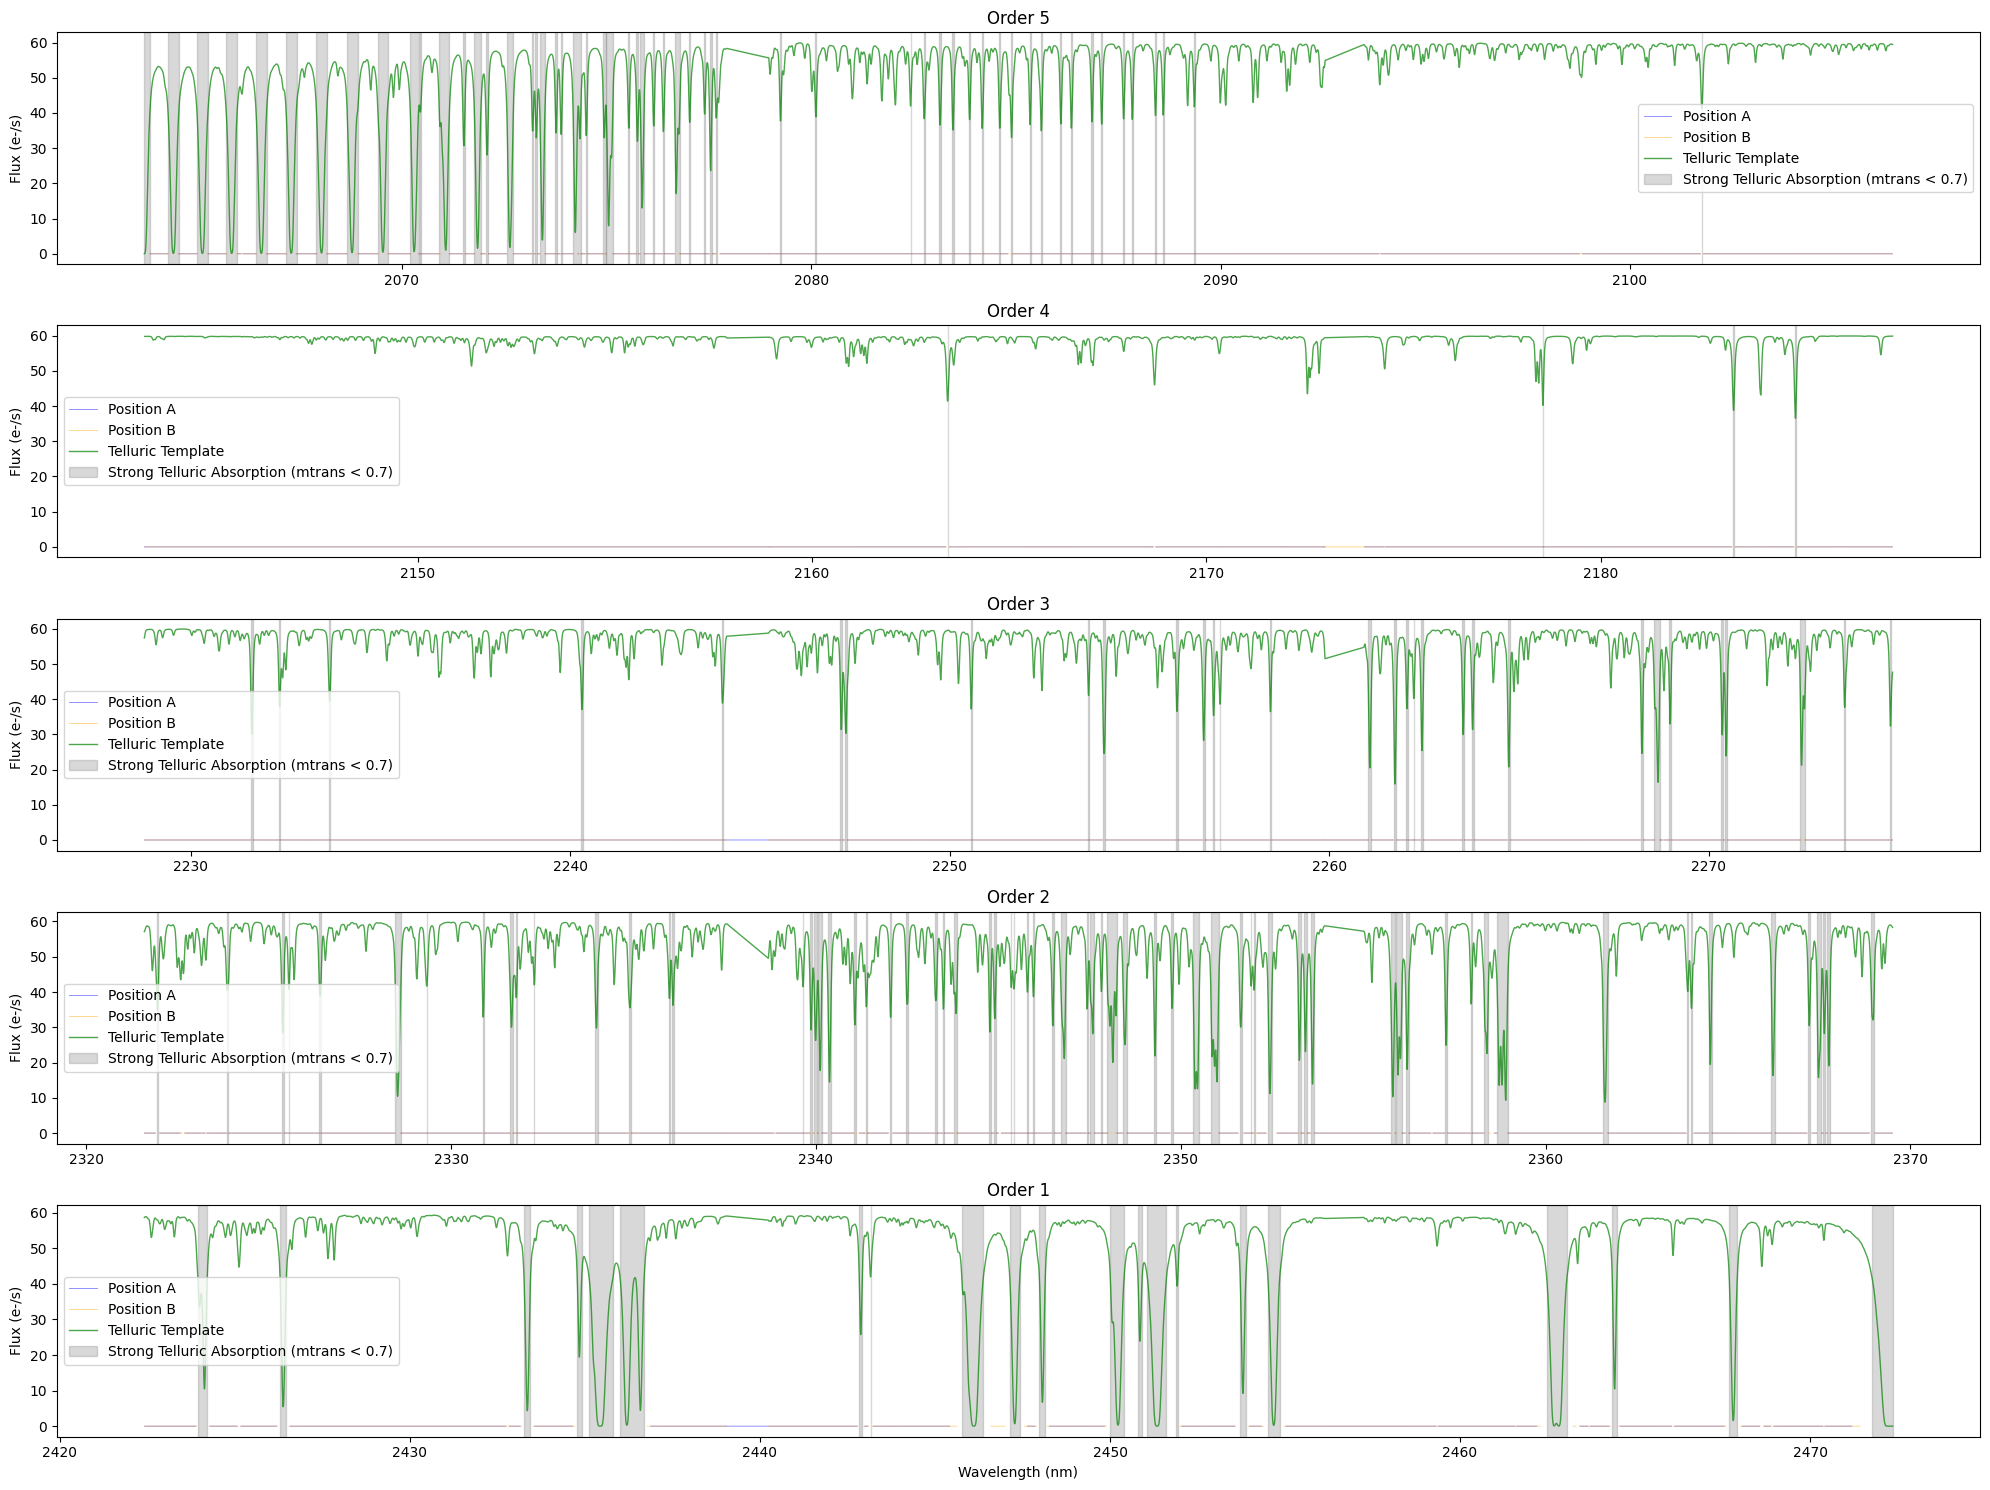

Chi Tau  effective airmass : 1.9038  (header value 1.568 only reflects the last 2 of 6 co-added frames)
DH Tau B effective airmass : 1.7007
Airmass scaling factor  α  : 0.8933  (< 1 → reduces over-correction / emission bumps)


In [2]:
extracted_spectra_A = np.load(workpath+ '/' + night+'/extracted_spectra_position_A_sigmaclipper_0417.npy')
extracted_spectra_B = np.load(workpath+ '/' + night+'/extracted_spectra_position_B_sigmaclipper_0417.npy')

extracted_spectra_A_err = np.load(workpath+ '/' + night+'/extracted_spectra_position_A_err_0417.npy')
extracted_spectra_B_err = np.load(workpath+ '/' + night+'/extracted_spectra_position_B_err_0417.npy')
telluric_hdu = fits.open(f'{workpath}{night}/chi_tau/{night}/out/molecfit/TELLURIC_DATA.fits')
telluric_template = np.array(telluric_hdu[1].data)

#First reshape the telluric template to (7, 3, 2048)
telluric_template = np.reshape(telluric_template, (7, 3, 2048))  # (7, 3, 2048)
#organize the shape from the last order to the first order
telluric_template = np.array([telluric_template[i] for i in range(0,7)][::-1])  # (7, 3, 2048)

#Second, convert the shape to (3, 7, 2048) to match the extracted spectra shape
telluric_template = np.transpose(telluric_template, (1,0,2))  # (3, 7, 2048)


wave_hdu = fits.open(workpath + night +'/cal/WLEN_K2166_V_DH_Tau_A+B_center.fits')
wave_data = np.array(wave_hdu[1].data)[:,0:5,]  # (3, 5, 2048)




#plot the extracted spectra for each order and overplot the telluric template

fig, axs = plt.subplots(5,1, figsize=(20,15), sharex=False)

for order in range(5):
    index_plt = 4 - order

    axs[index_plt].plot(wave_data[:,order,:].flatten(), extracted_spectra_A[:,order,:].flatten(), label='Position A', color='blue', alpha=0.5, linewidth=0.6)
    axs[index_plt].plot(wave_data[:,order,:].flatten(), extracted_spectra_B[:,order,:].flatten(), label='Position B', color='orange', alpha=0.5, linewidth=0.6)

    axs[index_plt].plot(telluric_template[:,order,:]['lambda'].flatten()*1e3, telluric_template[:,order,:]['mtrans'].flatten()*60, label='Telluric Template', color='green', alpha=0.7, linewidth=1)

    #mark the regions with strong telluric absorption (mtrans < 0.7)
    strong_telluric = telluric_template[:,order,:]['mtrans'].flatten() < 0.7
    axs[index_plt].fill_between(telluric_template[:,order,:]['lambda'].flatten()*1e3, 0, 1, where=strong_telluric, color='gray', alpha=0.3, transform=axs[index_plt].get_xaxis_transform(), label='Strong Telluric Absorption (mtrans < 0.7)')

    axs[index_plt].set_ylabel('Flux (e-/s)')
    axs[index_plt].set_title(f'Order {order+1}')
    axs[index_plt].legend()


axs[4].set_xlabel('Wavelength (nm)')
plt.tight_layout()
plt.show()
# ── Airmass rescaling of the telluric template ──────────────────────────────
# The FITS header of SPEC_chiTau_PRIMARY.fits records only the last frame's
# airmass (1.568). The combined spectrum spans 6 equal-exposure frames at
# airmasses [1.819, 1.808, 1.799, 1.789, 1.569, 1.568], giving a true
# effective airmass of ≈1.725.  DH Tau B was observed at a mean airmass of
# ≈1.700 (night 2022-12-31) or ≈1.695 (night 2023-01-01).
#
# Since Chi Tau's template is slightly TOO DEEP relative to DH Tau B,
# dividing by it over-corrects → emission bumps at telluric positions.
#
# Fix: rescale via the Beer–Lambert airmass power law:
#   T_target(λ) = T_ref(λ) ^ (X_target / X_ref)   with  alpha = X_target/X_ref < 1
# This makes the template slightly shallower before masking and correction.
import os as _os, glob as _glob

_chi_raw = _os.path.join(workpath, night.lstrip('/'), 'chi_tau', night.lstrip('/'), 'raw')
_chi_sci = sorted([f for f in _glob.glob(_os.path.join(_chi_raw, '*.fits'))
                   if 'OBS' in _os.path.basename(f)])
_chi_airm = [(fits.getheader(f)['ESO TEL AIRM START'] + fits.getheader(f)['ESO TEL AIRM END']) / 2
             for f in _chi_sci]

_dh_raw = _os.path.join(workpath, night.lstrip('/'), 'raw')
_dh_sci = sorted([f for f in _glob.glob(_os.path.join(_dh_raw, '*.fits'))
                  if 'OBS' in _os.path.basename(f)])
_dh_airm = [(fits.getheader(f)['ESO TEL AIRM START'] + fits.getheader(f)['ESO TEL AIRM END']) / 2
            for f in _dh_sci]

airmass_chitau = float(np.mean(_chi_airm))
airmass_dhtaub = float(np.mean(_dh_airm))
alpha_airmass  = airmass_dhtaub / airmass_chitau   # < 1 → shallower template

print(f"Chi Tau  effective airmass : {airmass_chitau:.4f}  "
      "(header value 1.568 only reflects the last 2 of 6 co-added frames)")
print(f"DH Tau B effective airmass : {airmass_dhtaub:.4f}")
print(f"Airmass scaling factor  α  : {alpha_airmass:.4f}  "
      "(< 1 → reduces over-correction / emission bumps)")

# Apply scaling; preserve zeros for fully opaque channels
# telluric_template['mtrans'] shape = (3, 7, 2048)
telluric_mtrans = np.where(telluric_template['mtrans'] > 0,
                            telluric_template['mtrans'] ** alpha_airmass,
                            0.0)  # shape (3, 7, 2048), dtype float

### 1.1b QA — wavelength-solution cross-check (molecfit vs WLEN_K2166)

Sanity check added after the telluric-template load: molecfit fits its own wavelength
solution to match the real telluric absorption seen in this night's data, so comparing
its `lambda` grid to the nominal `WLEN_K2166` arc/FP solution used everywhere below is a
direct, data-driven validation of the wavelength labels this notebook assigns to every
pixel. See `Cooking/cooking_wavelength_bary_validation.ipynb` for the full per-night
investigation (including an empirical telluric-line-position CCF check and the
barycentric-correction precision check), run in response to the tentative/offset
Na, Ca, HF cross-correlation detections.

In [ ]:
# ============================================================
# QA: wavelength-solution cross-check (added 2026-08-21)
# ============================================================
# Compares the WLEN_K2166 arc/FP wavelength solution (used to label every
# pixel below) against molecfit's own fitted telluric wavelength grid
# (TELLURIC_DATA.fits 'lambda') for this night, per (det, order) chip.
# molecfit refits the wavelength solution as part of matching its synthetic
# transmission spectrum to the real telluric absorption in the data, so a
# large disagreement here would mean WLEN_K2166 mislabels the true pixel
# wavelength -- which would bias any RV/CCF result derived from wave_data.
_c_kms = 299792.458
_tel_wave_check = telluric_template[:, 0:5, :]['lambda'] * 1e3   # (3,5,2048) nm
_dv_check = (_tel_wave_check - wave_data) / wave_data * _c_kms    # km/s

print(f'Wavelength-solution QA ({night}): WLEN_K2166 vs molecfit telluric grid')
print(f'{"chip (det,ord)":>16} {"median dv (km/s)":>18} {"std (km/s)":>12}')
_max_abs_median = 0.0
for _order in range(5):
    for _det in range(3):
        _d = _dv_check[_det, _order, :]
        _med, _std = np.nanmedian(_d), np.nanstd(_d)
        _max_abs_median = max(_max_abs_median, abs(_med))
        _flag = '  *** > 1 km/s ***' if abs(_med) > 1.0 else ''
        print(f'  ({_det},{_order}){"":>9} {_med:>+18.3f} {_std:>12.3f}{_flag}')
print(f'\nLargest |median offset| across all chips: {_max_abs_median:.3f} km/s')
if _max_abs_median <= 1.0:
    print('  OK -- WLEN_K2166 and the molecfit telluric grid agree to <1 km/s '
          'everywhere; no wavelength-solution correction needed before combination.')
else:
    print('  !! One or more chips disagree by >1 km/s -- inspect before trusting '
          'RVs/CCFs derived from wave_data for this night.')


## 1.2 Mark the wavelengths with transmission < 0.8

Sentinel pixels NaN-ified: A=3941  (threshold: err > 10  in file units)
NaN after sentinel mask: A=3941/30720  B=2870/30720


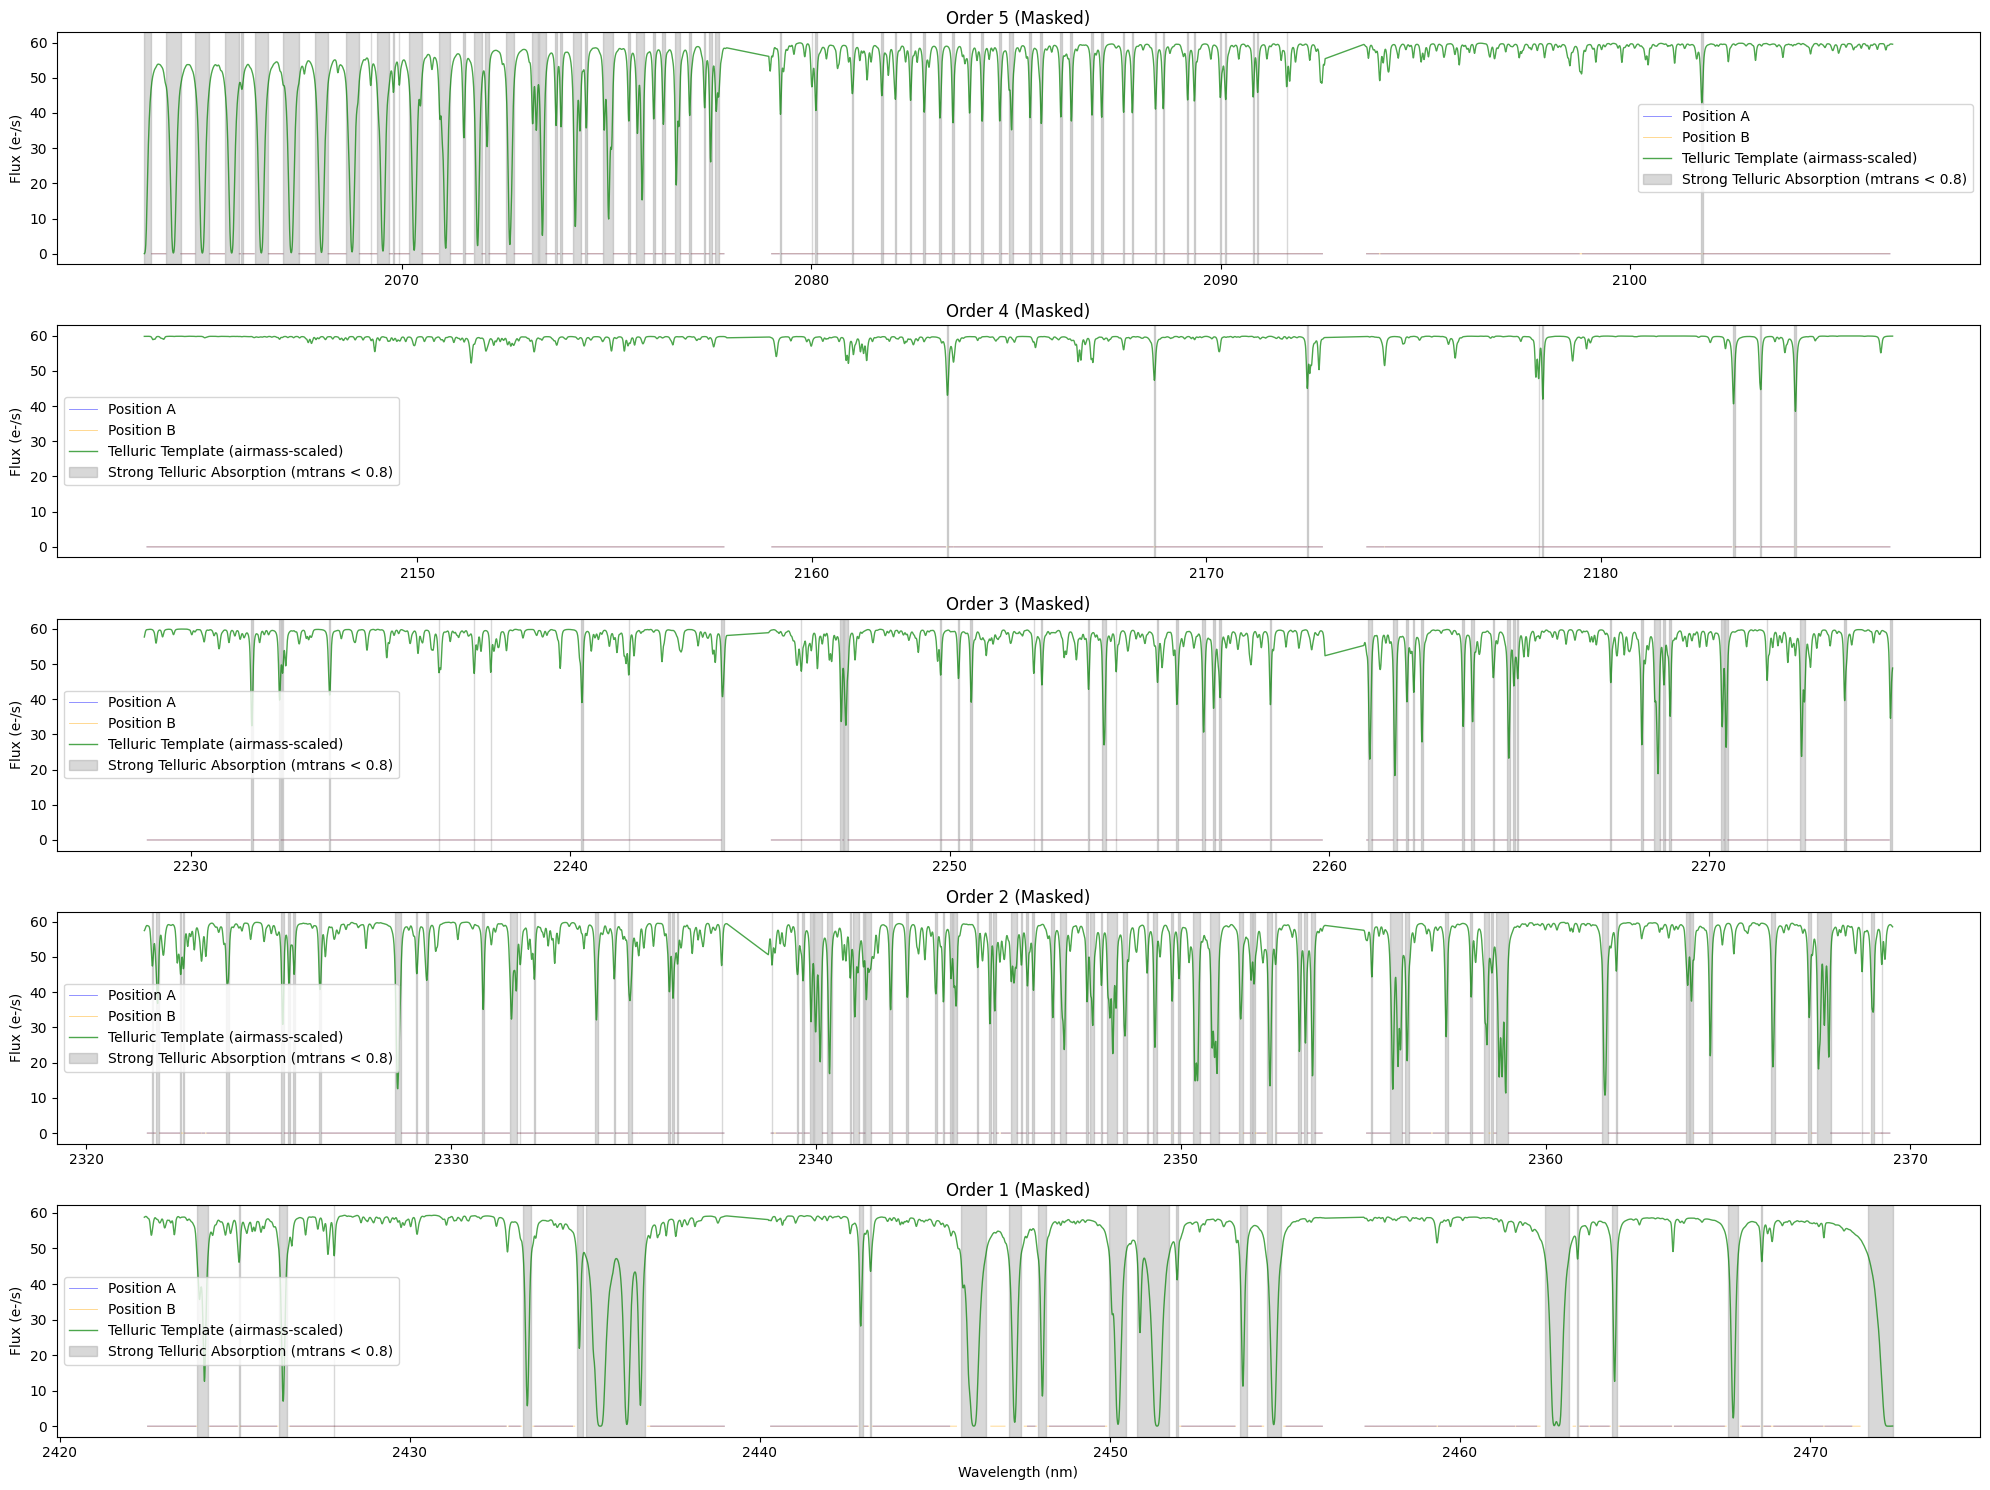

In [3]:
# --- Sentinel-pixel masking ---
# The sigma-clipped extraction files (.._sigmaclipper_0417.npy) have already
# processed excalibuhr's original 1e10-error sentinels: sigma-clipping reduces
# them to ~6e5–9.3e5 in the file units, all just below the old 1e6 threshold.
# The old condition also required flux==0.0 exactly, missing the ~10 % of
# sentinels whose flux was set to a tiny non-zero floating-point artifact.
# Result: ~269 bad pixels per order per position propagated through telluric
# correction and flux calibration, producing error spikes ~1e9 × the median.
#
# Fix: threshold on error alone (no flux==0 requirement), lowered to 0.1.
# Good pixels have max raw error ~0.013 (file units); 0.1 sits safely above
# that and well below the sentinel floor of ~6e5.
_SENTINEL_ERR = 10
for _f, _e in [(extracted_spectra_A, extracted_spectra_A_err),
               (extracted_spectra_B, extracted_spectra_B_err)]:
    _sentinel = _e > _SENTINEL_ERR
    _f[_sentinel] = np.nan
    _e[_sentinel] = np.nan

_n_sent_A = np.isnan(extracted_spectra_A[:, 0:5, :]).sum() - np.isnan(extracted_spectra_A[:, 0:5, :] * 0).sum()
print(f'Sentinel pixels NaN-ified: '
      f'A={np.sum(extracted_spectra_A_err[:,0:5,:] != extracted_spectra_A_err[:,0:5,:])}'
      f'  (threshold: err > {_SENTINEL_ERR}  in file units)')

# simpler count: how many finite err remain vs. started
_n_total = extracted_spectra_A_err[:, 0:5, :].size
_n_nan_A = np.isnan(extracted_spectra_A_err[:, 0:5, :]).sum()
_n_nan_B = np.isnan(extracted_spectra_B_err[:, 0:5, :]).sum()
print(f'NaN after sentinel mask: A={_n_nan_A}/{_n_total}  B={_n_nan_B}/{_n_total}')

# --- Telluric mask: set pixels with transmission < 0.8 to NaN ---
mask_A = np.ones_like(extracted_spectra_A, dtype=bool)
mask_B = np.ones_like(extracted_spectra_B, dtype=bool)

for order in range(5):
    telluric_mtrans_order = telluric_mtrans[:,order,:]
    strong_telluric = telluric_mtrans_order < 0.8

    mask_A[:,order,:] = ~strong_telluric
    mask_B[:,order,:] = ~strong_telluric

extracted_spectra_A_masked = np.where(mask_A, extracted_spectra_A, np.nan)
extracted_spectra_B_masked = np.where(mask_B, extracted_spectra_B, np.nan)
extracted_spectra_A_err_masked = np.where(mask_A, extracted_spectra_A_err, np.nan)
extracted_spectra_B_err_masked = np.where(mask_B, extracted_spectra_B_err, np.nan)

#again plot the extracted spectra for each order after masking telluric regions and telluric template following the previous plotting code
fig, axs = plt.subplots(5,1, figsize=(20,15), sharex=False)

for order in range(5):
    index_plt = 4 - order

    axs[index_plt].plot(wave_data[:,order,:].flatten(), extracted_spectra_A_masked[:,order,:].flatten(), label='Position A', color='blue', alpha=0.5, linewidth=0.6)
    axs[index_plt].plot(wave_data[:,order,:].flatten(), extracted_spectra_B_masked[:,order,:].flatten(), label='Position B', color='orange', alpha=0.5, linewidth=0.6)

    axs[index_plt].plot(telluric_template[:,order,:]['lambda'].flatten()*1e3, telluric_mtrans[:,order,:].flatten()*60, label='Telluric Template (airmass-scaled)', color='green', alpha=0.7, linewidth=1)

    #mark the regions with strong telluric absorption (mtrans < 0.8)
    strong_telluric = telluric_mtrans[:,order,:].flatten() < 0.8
    axs[index_plt].fill_between(telluric_template[:,order,:]['lambda'].flatten()*1e3, 0, 1, where=strong_telluric, color='gray', alpha=0.3, transform=axs[index_plt].get_xaxis_transform(), label='Strong Telluric Absorption (mtrans < 0.8)')

    axs[index_plt].set_ylabel('Flux (e-/s)')
    axs[index_plt].set_title(f'Order {order+1} (Masked)')
    axs[index_plt].legend()
axs[4].set_xlabel('Wavelength (nm)')
plt.tight_layout()
plt.show()

#save the masked extracted spectra and errors
np.save(workpath+ night+'/extracted_spectra_position_A_masked.npy', extracted_spectra_A_masked)
np.save(workpath+ night+'/extracted_spectra_position_B_masked.npy', extracted_spectra_B_masked)
np.save(workpath+ night+'/extracted_spectra_position_A_err_masked.npy', extracted_spectra_A_err_masked)
np.save(workpath+ night+'/extracted_spectra_position_B_err_masked.npy', extracted_spectra_B_err_masked)


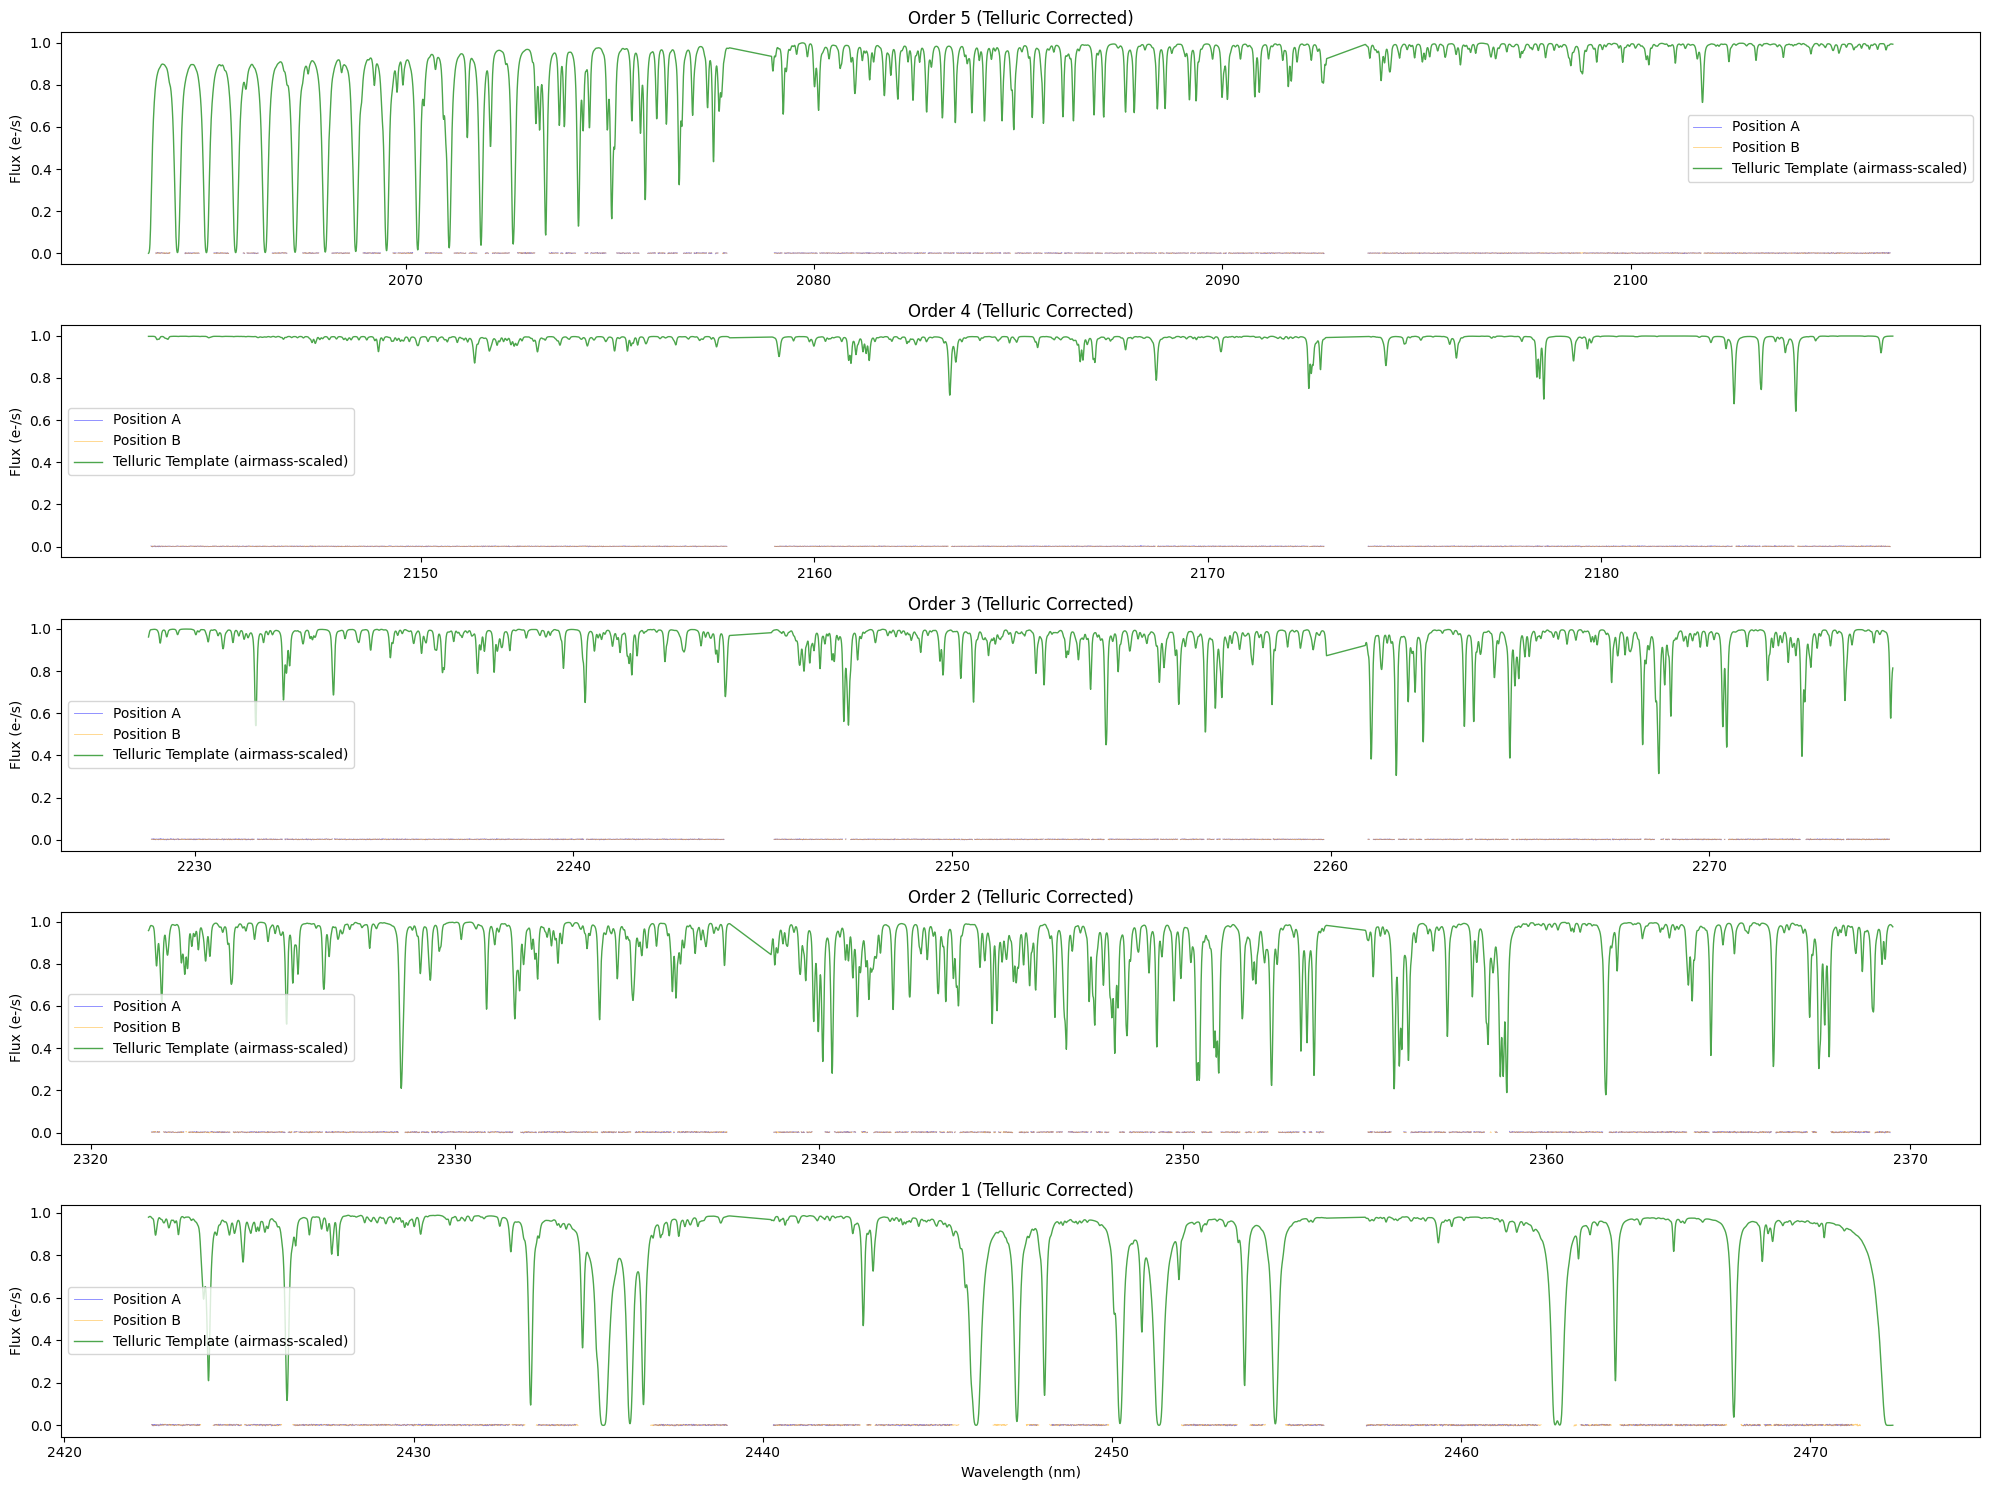

In [4]:
#correct the tellurics by dividing the extracted spectra by the telluric template for both positions
extracted_spectra_A_corrected = extracted_spectra_A_masked / telluric_mtrans[:,0:5,:]
extracted_spectra_B_corrected = extracted_spectra_B_masked / telluric_mtrans[:,0:5,:]

#again plot the extracted spectra for each order after telluric correction following the previous plotting code
fig, axs = plt.subplots(5,1, figsize=(20,15), sharex=False)
for order in range(5):
    index_plt = 4 - order

    axs[index_plt].plot(wave_data[:,order,:].flatten(), extracted_spectra_A_corrected[:,order,:].flatten(), label='Position A', color='blue', alpha=0.5, linewidth=0.6)
    axs[index_plt].plot(wave_data[:,order,:].flatten(), extracted_spectra_B_corrected[:,order,:].flatten(), label='Position B', color='orange', alpha=0.5, linewidth=0.6)

    axs[index_plt].plot(telluric_template[:,order,:]['lambda'].flatten()*1e3, telluric_mtrans[:,order,:].flatten(), label='Telluric Template (airmass-scaled)', color='green', alpha=0.7, linewidth=1)

    axs[index_plt].set_ylabel('Flux (e-/s)')
    axs[index_plt].set_title(f'Order {order+1} (Telluric Corrected)')
    axs[index_plt].legend()
axs[4].set_xlabel('Wavelength (nm)')
plt.tight_layout()
plt.show()

# 2. Absolute flux calibration

## 2.1 Run absolute flux calibration with SIFONI data

SINFONI absolute correction: 1.3346e+08
  DH Tau B K=14.19: expected 9.0460e-16 W m⁻² µm⁻¹
  SINFONI file K-band median before correction: 6.7781e-24
SINFONI valid range : 1100.0 – 2457.9 nm
CRIRES+ range       : 2063.70 – 2472.35 nm

Per-chip pixel-level ratio collection:
  det0 ord0: 1522 pts  wc=2429.9 nm  median=3.4049e-13
  det0 ord1: 1749 pts  wc=2329.7 nm  median=3.9110e-13
  det0 ord2: 1972 pts  wc=2236.6 nm  median=4.7475e-13
  det0 ord3: 1991 pts  wc=2150.5 nm  median=5.6079e-13
  det0 ord4: 1162 pts  wc=2071.4 nm  median=5.8715e-13
  det1 ord0: 1279 pts  wc=2446.9 nm  median=3.4393e-13
  det1 ord1: 1407 pts  wc=2346.2 nm  median=4.1697e-13
  det1 ord2: 1883 pts  wc=2252.6 nm  median=4.9379e-13
  det1 ord3: 2007 pts  wc=2166.0 nm  median=5.5732e-13
  det1 ord4: 1773 pts  wc=2085.9 nm  median=5.9239e-13
  det2 ord0: SINFONI coverage 4.5% < 20% (wc=2457.6 nm) → extrapolated
  det2 ord1: 1596 pts  wc=2362.5 nm  median=3.8665e-13
  det2 ord2: 1803 pts  wc=2267.9 nm  median=4.9137

/var/tmp/peng/ipykernel_2027436/1888557784.py:73: RuntimeWarning: Mean of empty slice
  crires_mean = np.nanmean(np.array([A_chip, B_chip]), axis=0)


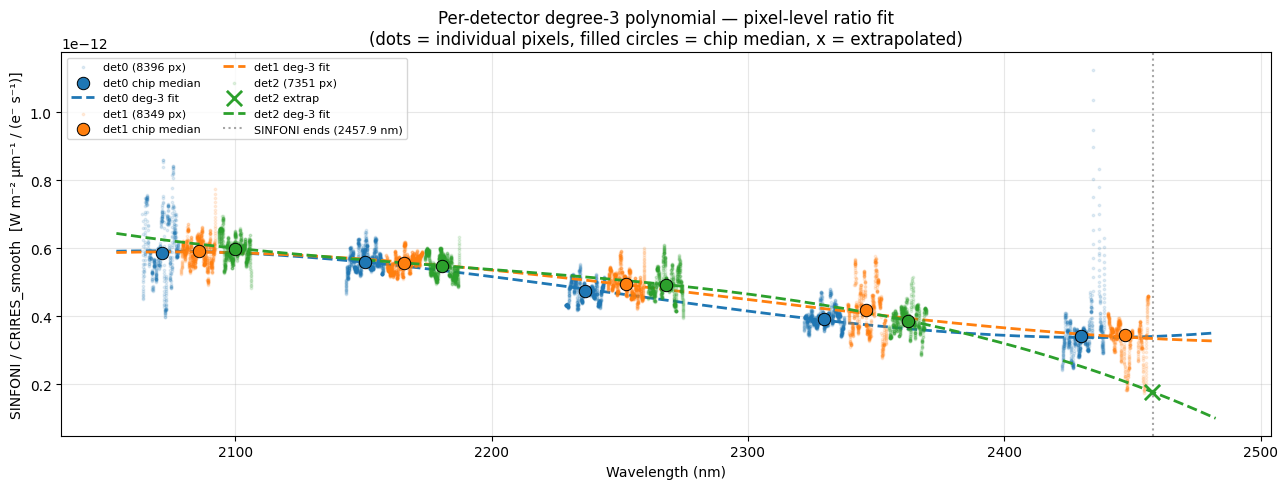

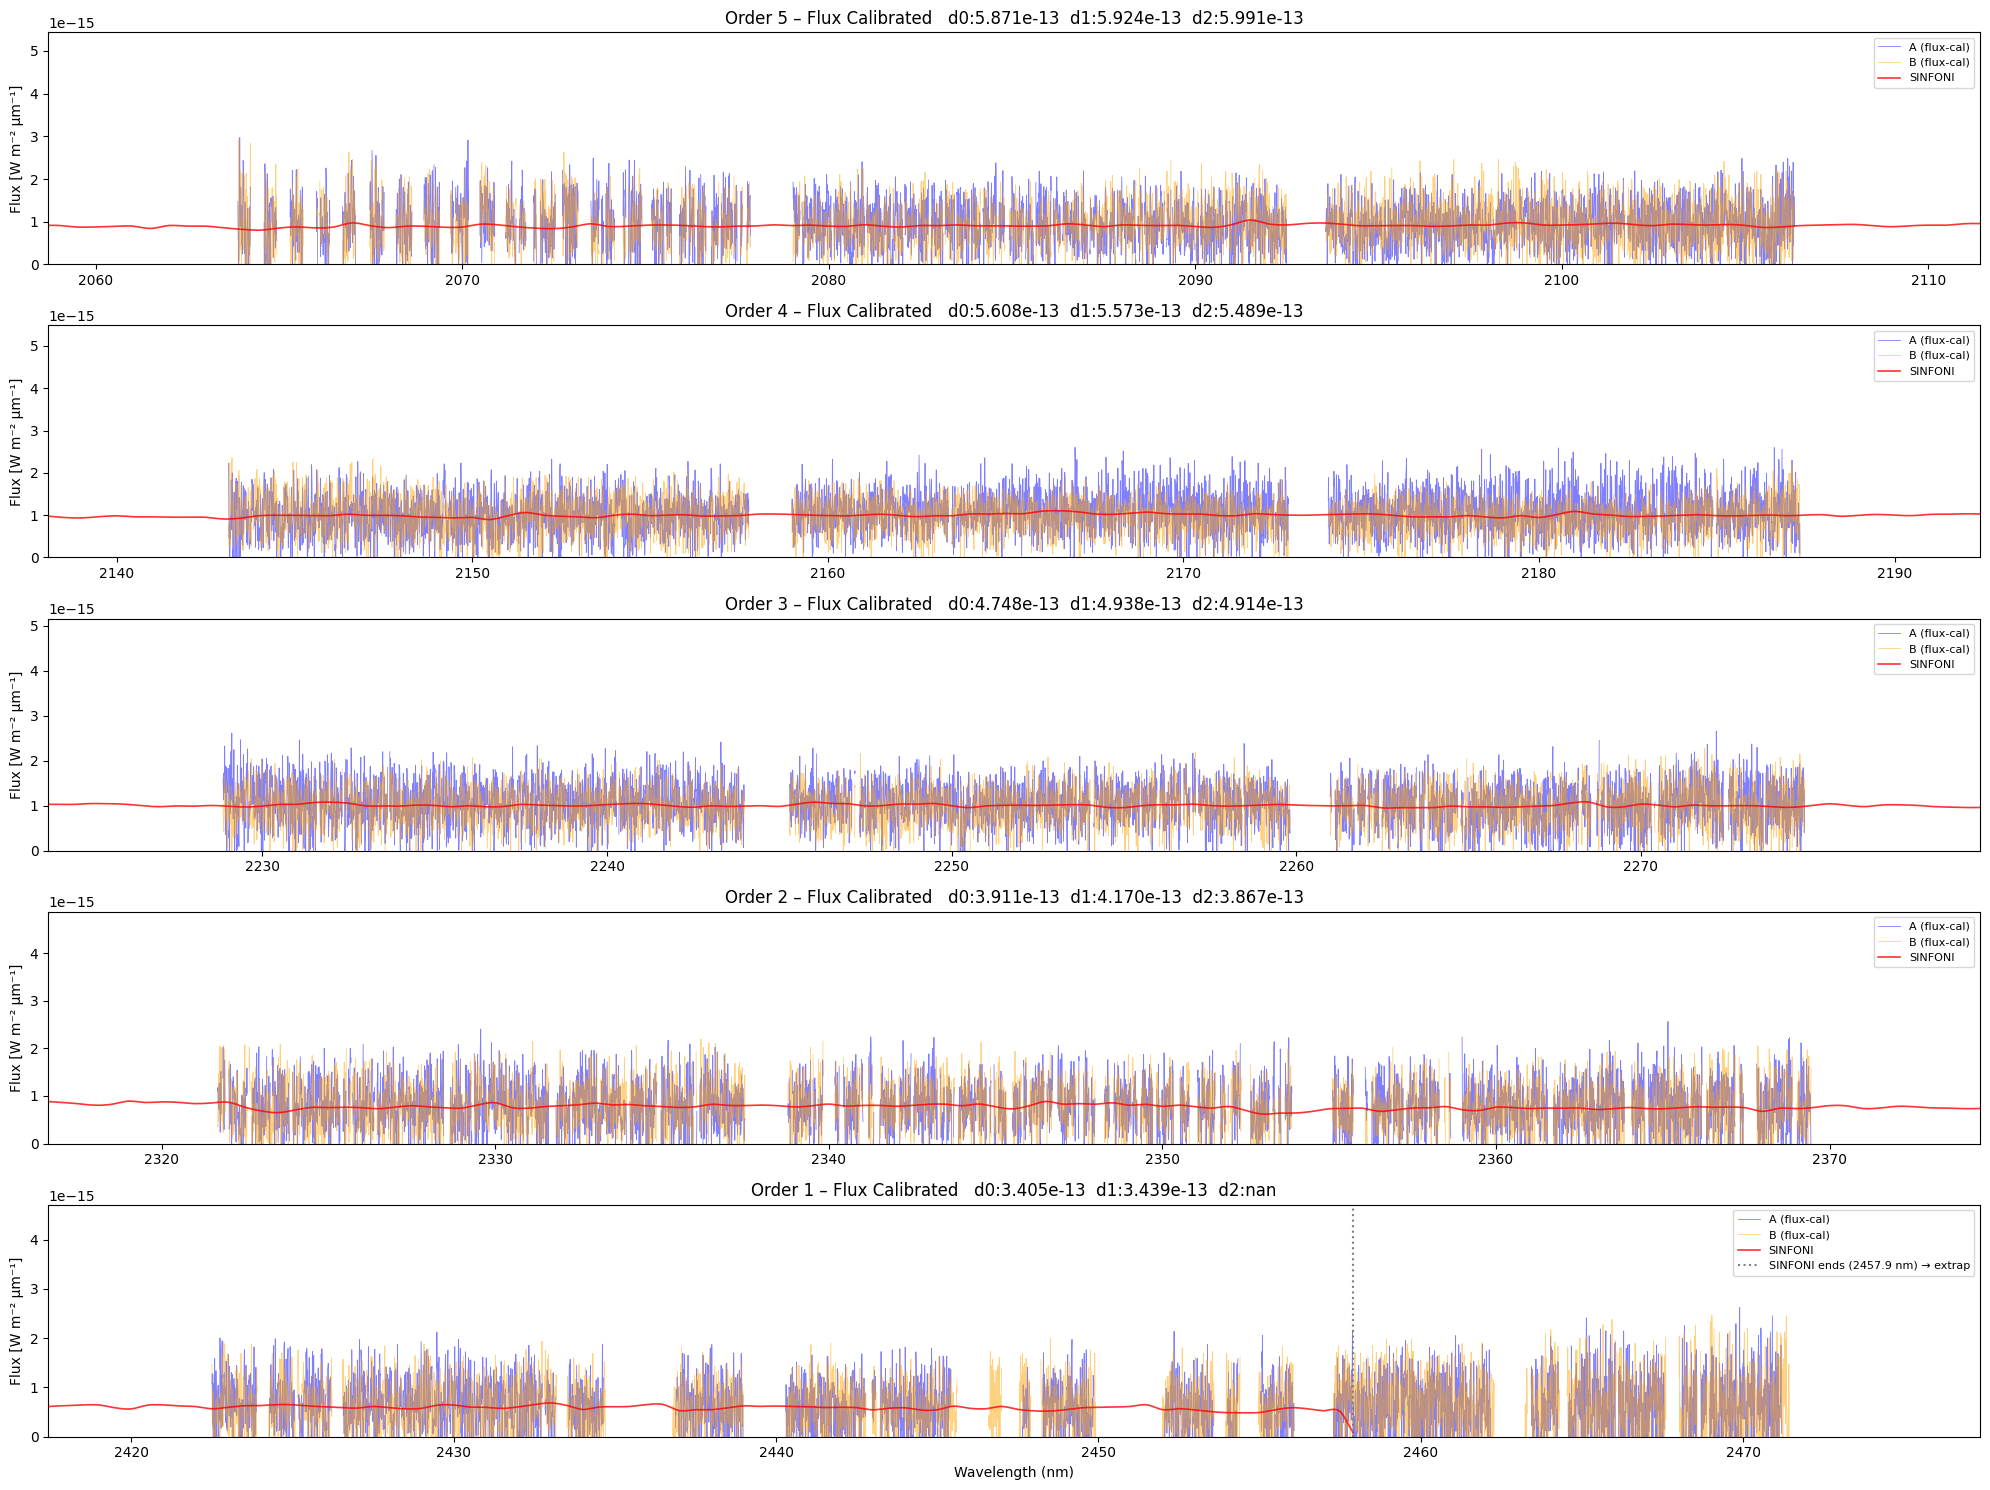

Saved flux-calibrated spectra (A, B) and propagated errors.


In [5]:

# ============================================================
# Absolute Flux Calibration using SINFONI data
# ============================================================
#
# SINFONI coverage (non-zero): 1100 – 2458.5 nm
# CRIRES+ K2166 coverage:      2063.7 – 2472.4 nm
# Overlap:                     2063.7 – 2458.5 nm
#
# Strategy (pixel-level ratio, per-detector degree-3 polynomial):
#   1. Anchor SINFONI to 2MASS K_s photometry.
#   2. Interpolate SINFONI onto CRIRES+ pixel grid.
#   3. Per chip: smooth CRIRES+ with SavGol (201 px ≈ 20 nm).
#      NaN gaps (masked telluric pixels) are filled by linear interpolation
#      BEFORE SavGol — zero-filling biases the smooth downward near telluric
#      clusters, inflating the ratio and over-calibrating those chips.
#      Then compute pixel-level ratio SINFONI/CRIRES_smooth; 3σ-clip per chip.
#   4. Collect all valid (wavelength, ratio) points per detector (~5000–8000/det).
#      Fit a degree-3 polynomial per detector with 3-pass iterative σ-clipping.
#      Separate fits capture inter-detector level offsets; degree-3 captures
#      genuine curvature. Chips with <20 SINFONI px are extrapolated.
#   5. Apply the per-detector polynomial smoothly per pixel.
#   6. Propagate scale to error arrays.
#
from scipy.interpolate import interp1d

# ---- 1. Load SINFONI spectrum ----
sinfoni_hdu = fits.open(workpath + '/DHTaub_SINFONIspeclib_JHK.fits')
sinfoni_raw  = sinfoni_hdu[0].data
sinfoni_wave = sinfoni_raw[:, 0] * 1e3       # µm → nm
sinfoni_flux = sinfoni_raw[:, 1]

# Absolute photometric anchor: DH Tau B K_s=14.19 (Patience+2012 Table 2, 2MASS K_s).
_K_dhtaub     = 14.19
_F0_K_Vega    = 4.29e-10       # 2MASS K_s Vega zero-point, W m⁻² µm⁻¹
_F_K_expected = _F0_K_Vega * 10**(-_K_dhtaub / 2.5)
_wl_K         = (sinfoni_raw[:, 0] >= 2.0) & (sinfoni_raw[:, 0] <= 2.5)
_sif_K_median = np.nanmedian(sinfoni_flux[_wl_K & (sinfoni_flux > 0)])
_sif_abs_corr = _F_K_expected / _sif_K_median
sinfoni_flux  = sinfoni_flux * _sif_abs_corr
print(f'SINFONI absolute correction: {_sif_abs_corr:.4e}')
print(f'  DH Tau B K={_K_dhtaub}: expected {_F_K_expected:.4e} W m⁻² µm⁻¹')
print(f'  SINFONI file K-band median before correction: {_sif_K_median:.4e}')

_sif_kmed_cal = np.nanmedian(sinfoni_flux[_wl_K & (sinfoni_flux > 0)])
sif_valid  = np.isfinite(sinfoni_flux) & (sinfoni_flux > 1e-3 * _sif_kmed_cal)  # exclude near-zero edge pixels (< 0.1% K-band med)
sif_wave_v = sinfoni_wave[sif_valid]
sif_flux_v = sinfoni_flux[sif_valid]
print(f'SINFONI valid range : {sif_wave_v.min():.1f} – {sif_wave_v.max():.1f} nm')
print(f'CRIRES+ range       : {wave_data.min():.2f} – {wave_data.max():.2f} nm')

sinfoni_interp = interp1d(sif_wave_v, sif_flux_v, kind='cubic',
                          bounds_error=False, fill_value=np.nan)

# ---- 2. Interpolate SINFONI onto CRIRES+ pixel grid ----
sinfoni_on_crires = sinfoni_interp(wave_data)   # (3, 5, 2048)

# ---- 3. Collect pixel-level ratio (SINFONI / CRIRES_smooth) per detector ----
det_wave_pts  = {d: [] for d in range(3)}
det_ratio_pts = {d: [] for d in range(3)}
scale_chips   = np.full((3, 5), np.nan)    # per-chip median ratio (diagnostic)
scale_wc      = np.full((3, 5), np.nan)    # chip central wavelength
has_sinfoni   = np.full((3, 5), False, dtype=bool)

print('\nPer-chip pixel-level ratio collection:')
for det in range(3):
    for order in range(5):
        w_chip    = wave_data[det, order, :]
        sif_chip  = sinfoni_on_crires[det, order, :]
        A_chip    = extracted_spectra_A_corrected[det, order, :]
        B_chip    = extracted_spectra_B_corrected[det, order, :]

        sif_mask    = np.isfinite(sif_chip) & (sif_chip > 0)
        crires_mean = np.nanmean(np.array([A_chip, B_chip]), axis=0)
        data_mask   = np.isfinite(crires_mean) & (crires_mean > 0)
        joint_mask  = sif_mask & data_mask

        scale_wc[det, order] = (np.nanmedian(w_chip[joint_mask])
                                if joint_mask.any() else np.nanmedian(w_chip))

        if joint_mask.sum() < 20:
            print(f'  det{det} ord{order}: only {joint_mask.sum()} SINFONI pix '
                  f'(wc={scale_wc[det,order]:.1f} nm) → extrapolated')
            continue

        # Treat chips where SINFONI covers < 20% of pixels as extrapolated:
        # sparse coverage at the SINFONI detector cutoff edge gives biased ratios.
        _coverage = joint_mask.sum() / max(1, np.isfinite(crires_mean).sum())
        if _coverage < 0.20:
            print(f'  det{det} ord{order}: SINFONI coverage {_coverage:.1%} < 20% '
                  f'(wc={scale_wc[det,order]:.1f} nm) → extrapolated')
            continue

        # SavGol with linear-interpolated gap-fill (NOT zero-fill).
        # Zero-filling NaN gaps near telluric clusters biases the smooth
        # downward, inflating ratio = SINFONI/CRIRES_smooth at those pixels.
        fin = np.isfinite(crires_mean)
        crires_smooth = np.full_like(crires_mean, np.nan)
        if fin.sum() > 201:
            x_px  = np.arange(len(crires_mean), dtype=float)
            f_gap = interp1d(x_px[fin], crires_mean[fin], kind='linear',
                             bounds_error=False,
                             fill_value=(crires_mean[fin][0], crires_mean[fin][-1]))
            crires_filled = f_gap(x_px)
            row_s = savgol_filter(crires_filled, window_length=201, polyorder=2)
            crires_smooth = np.where(fin, row_s, np.nan)
        else:
            crires_smooth = np.where(fin, crires_mean, np.nan)

        smooth_mask = joint_mask & np.isfinite(crires_smooth) & (crires_smooth > 0)
        if smooth_mask.sum() < 20:
            print(f'  det{det} ord{order}: too few smooth pixels → skip')
            continue

        ratio = sif_chip[smooth_mask] / crires_smooth[smooth_mask]
        w_pts = w_chip[smooth_mask]

        # Per-chip 3σ clip removes telluric residuals / bad pixels
        med, std = np.nanmedian(ratio), np.nanstd(ratio)
        keep = (np.abs(ratio - med) < 3 * std) if std > 0 else np.ones(len(ratio), dtype=bool)
        if keep.sum() < 10:
            keep = np.ones(len(ratio), dtype=bool)

        det_wave_pts[det].append(w_pts[keep])
        det_ratio_pts[det].append(ratio[keep])
        has_sinfoni[det, order] = True
        scale_chips[det, order] = np.nanmedian(ratio[keep])
        print(f'  det{det} ord{order}: {keep.sum():4d} pts  '
              f'wc={scale_wc[det,order]:.1f} nm  median={scale_chips[det,order]:.4e}')

for det in range(3):
    det_wave_pts[det]  = (np.concatenate(det_wave_pts[det])  if det_wave_pts[det]  else np.array([]))
    det_ratio_pts[det] = (np.concatenate(det_ratio_pts[det]) if det_ratio_pts[det] else np.array([]))

# ---- 4. Per-detector degree-3 polynomial fit with iterative σ-clipping ----
POLY_DEG  = 3
det_polys = {}
det_cols  = ['#1f77b4', '#ff7f0e', '#2ca02c']

print(f'\nPer-detector degree-{POLY_DEG} polynomial fits (3-pass iterative σ-clip):')
for det in range(3):
    w_all = det_wave_pts[det]
    r_all = det_ratio_pts[det]
    if len(w_all) < POLY_DEG + 2:
        print(f'  det{det}: only {len(w_all)} pts → global median fallback')
        det_polys[det] = None
        continue

    valid = np.ones(len(w_all), dtype=bool)
    for _iter in range(3):
        coef  = np.polyfit(w_all[valid], r_all[valid], deg=POLY_DEG)
        poly  = np.poly1d(coef)
        resid = r_all - poly(w_all)
        sigma = np.nanstd(resid[valid])
        new_v = np.abs(resid) < 3 * sigma
        if new_v.sum() == valid.sum():
            break
        if new_v.sum() < POLY_DEG + 2:
            break
        valid = new_v

    coef = np.polyfit(w_all[valid], r_all[valid], deg=POLY_DEG)
    det_polys[det] = np.poly1d(coef)
    n_extrap = (~has_sinfoni[det]).sum()
    note = f'  [{n_extrap} chip extrapolated]' if n_extrap else ''
    print(f'  det{det}: {valid.sum()}/{len(w_all)} pts used{note}  '
          f'coef={np.array2string(np.array(coef), precision=3, suppress_small=True)}')

# ---- Diagnostic: pixel scatter + per-chip medians + polynomial fits ----
fig_sc, ax_sc = plt.subplots(figsize=(13, 5))
for det in range(3):
    w_all = det_wave_pts[det]
    r_all = det_ratio_pts[det]
    if len(w_all) > 0:
        step = max(1, len(w_all) // 3000)
        ax_sc.scatter(w_all[::step], r_all[::step], color=det_cols[det],
                      s=3, alpha=0.12, zorder=2, label=f'det{det} ({len(w_all)} px)')
    for order in range(5):
        if has_sinfoni[det, order]:
            ax_sc.scatter(scale_wc[det, order], scale_chips[det, order],
                          color=det_cols[det], s=80, zorder=5,
                          edgecolors='k', linewidths=0.7,
                          label='_' if order > 0 else f'det{det} chip median')
        elif det_polys[det] is not None:
            ax_sc.scatter(scale_wc[det, order], det_polys[det](scale_wc[det, order]),
                          color=det_cols[det], marker='x', s=120, linewidths=2,
                          zorder=6, label=f'det{det} extrap')
    if det_polys[det] is not None:
        w_fit = np.linspace(wave_data.min() - 10, wave_data.max() + 10, 500)
        ax_sc.plot(w_fit, det_polys[det](w_fit), color=det_cols[det],
                   lw=2, ls='--', label=f'det{det} deg-{POLY_DEG} fit')

ax_sc.axvline(sif_wave_v.max(), color='gray', ls=':', alpha=0.7,
              label=f'SINFONI ends ({sif_wave_v.max():.1f} nm)')
ax_sc.set_xlabel('Wavelength (nm)')
ax_sc.set_ylabel('SINFONI / CRIRES_smooth  [W m⁻² µm⁻¹ / (e⁻ s⁻¹)]')
ax_sc.set_title(f'Per-detector degree-{POLY_DEG} polynomial — pixel-level ratio fit\n'
                '(dots = individual pixels, filled circles = chip median, x = extrapolated)')
ax_sc.legend(fontsize=8, ncol=2)
ax_sc.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(workpath + night + '/flux_cal_scale_factors.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- 5. Apply per-detector polynomial scale per pixel ----
extracted_spectra_A_flux_cal     = np.full_like(extracted_spectra_A_corrected, np.nan)
extracted_spectra_B_flux_cal     = np.full_like(extracted_spectra_B_corrected, np.nan)

extracted_spectra_A_err_corrected = extracted_spectra_A_err_masked / telluric_mtrans[:, 0:5, :]
extracted_spectra_B_err_corrected = extracted_spectra_B_err_masked / telluric_mtrans[:, 0:5, :]

extracted_spectra_A_err_flux_cal = np.full_like(extracted_spectra_A_err_corrected, np.nan)
extracted_spectra_B_err_flux_cal = np.full_like(extracted_spectra_B_err_corrected, np.nan)

_all_ratios     = [det_ratio_pts[d] for d in range(3) if len(det_ratio_pts[d]) > 0]
_fallback_scale = np.nanmedian(np.concatenate(_all_ratios)) if _all_ratios else 1.0
# Per-detector clamp: freeze the polynomial at the last wavelength with SINFONI data.
# Degree-3 extrapolation far beyond the last data point accelerates (cubic ringing);
# clamping at the last chip center wavelength gives a physically stable flat extension.
det_clamp_wl = {}
for _det in range(3):
    _covered_wc = [scale_wc[_det, _ord] for _ord in range(5) if has_sinfoni[_det, _ord]]
    det_clamp_wl[_det] = max(_covered_wc) if _covered_wc else sif_wave_v.max()

for det in range(3):
    _poly_at_clamp = (det_polys[det](det_clamp_wl[det]) if det_polys[det] is not None
                      else _fallback_scale)
    for order in range(5):
        w_chip    = wave_data[det, order, :]
        scale_map = (det_polys[det](w_chip) if det_polys[det] is not None
                     else np.full_like(w_chip, _fallback_scale))
        scale_map = np.where(w_chip > det_clamp_wl[det], _poly_at_clamp, scale_map)
        extracted_spectra_A_flux_cal[det, order, :]     = extracted_spectra_A_corrected[det, order, :] * scale_map
        extracted_spectra_B_flux_cal[det, order, :]     = extracted_spectra_B_corrected[det, order, :] * scale_map
        extracted_spectra_A_err_flux_cal[det, order, :] = extracted_spectra_A_err_corrected[det, order, :] * scale_map
        extracted_spectra_B_err_flux_cal[det, order, :] = extracted_spectra_B_err_corrected[det, order, :] * scale_map

# ---- 6. Diagnostic: compare flux-calibrated spectra against SINFONI ----
fig, axs = plt.subplots(5, 1, figsize=(20, 15), sharex=False)

for order in range(5):
    idx = 4 - order
    w   = wave_data[:, order, :].flatten()

    axs[idx].plot(w, extracted_spectra_A_flux_cal[:, order, :].flatten(),
                  label='A (flux-cal)', color='blue', alpha=0.5, linewidth=0.6)
    axs[idx].plot(w, extracted_spectra_B_flux_cal[:, order, :].flatten(),
                  label='B (flux-cal)', color='orange', alpha=0.5, linewidth=0.6)

    sif_sel = (sif_wave_v >= w.min() - 10) & (sif_wave_v <= w.max() + 10)
    axs[idx].plot(sif_wave_v[sif_sel], sif_flux_v[sif_sel],
                  label='SINFONI', color='red', alpha=0.8, linewidth=1.2)

    if order == 0:
        axs[idx].axvline(sif_wave_v.max(), color='gray', linestyle=':',
                         label=f'SINFONI ends ({sif_wave_v.max():.1f} nm) → extrap')

    chip_scales_str = '  '.join([f'd{d}:{scale_chips[d,order]:.3e}' for d in range(3)])
    axs[idx].set_ylabel('Flux [W m⁻² µm⁻¹]')
    axs[idx].set_title(f'Order {order+1} – Flux Calibrated   {chip_scales_str}')
    axs[idx].legend(fontsize=8)
    axs[idx].set_xlim(w.min() - 5, w.max() + 5)

    _a = extracted_spectra_A_flux_cal[:, order, :].flatten()
    _b = extracted_spectra_B_flux_cal[:, order, :].flatten()
    _a = _a[np.isfinite(_a)]; _b = _b[np.isfinite(_b)]
    ymax_v = max(
        np.nanpercentile(_a, 99) if len(_a) else 0,
        np.nanpercentile(_b, 99) if len(_b) else 0,
        np.nanmax(sif_flux_v[sif_sel]) if sif_sel.any() else 0,
    )
    axs[idx].set_ylim(0, ymax_v * 2.5)

axs[4].set_xlabel('Wavelength (nm)')
plt.tight_layout()
plt.savefig(workpath + night + '/flux_cal_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- 7. Save flux-calibrated spectra ----
np.save(workpath + night + '/extracted_spectra_position_A_flux_cal.npy',     extracted_spectra_A_flux_cal)
np.save(workpath + night + '/extracted_spectra_position_B_flux_cal.npy',     extracted_spectra_B_flux_cal)
np.save(workpath + night + '/extracted_spectra_position_A_err_flux_cal.npy', extracted_spectra_A_err_flux_cal)
np.save(workpath + night + '/extracted_spectra_position_B_err_flux_cal.npy', extracted_spectra_B_err_flux_cal)
print('Saved flux-calibrated spectra (A, B) and propagated errors.')


In [6]:

# ---- Combine the two positions using flux-calibrated spectra ----
# Formal error propagation (LPU / GUM §5): for f = (A + B) / N,
# sigma_f = sqrt(sigma_A^2 + sigma_B^2) / N.
# For N=2, median == mean exactly, so the same formula applies.
# n_valid handles pixels where one nod is NaN: error is then just the single valid error.

extracted_spectra_combined = np.nanmedian(
    np.array([extracted_spectra_A_flux_cal, extracted_spectra_B_flux_cal]), axis=0)

_stack_fc     = np.array([extracted_spectra_A_flux_cal, extracted_spectra_B_flux_cal])
_err_stack_fc = np.array([extracted_spectra_A_err_flux_cal, extracted_spectra_B_err_flux_cal])
_n_valid_fc   = np.sum(np.isfinite(_stack_fc), axis=0)          # 0, 1, or 2 per pixel
extracted_spectra_combined_err = np.where(
    _n_valid_fc > 0,
    np.sqrt(np.nansum(_err_stack_fc**2, axis=0)) / _n_valid_fc,
    np.nan)

# Save the combined flux-calibrated spectra
np.save(workpath + '/' + night + '/extracted_spectra_combined_flux_cal.npy',
        extracted_spectra_combined)
np.save(workpath + '/' + night + '/extracted_spectra_combined_err_flux_cal.npy',
        extracted_spectra_combined_err)

# Also save the non-flux-calibrated combined spectra (kept for reference)
extracted_spectra_combined_raw = np.nanmedian(
    np.array([extracted_spectra_A_corrected, extracted_spectra_B_corrected]), axis=0)

_stack_raw     = np.array([extracted_spectra_A_corrected, extracted_spectra_B_corrected])
_err_stack_raw = np.array([extracted_spectra_A_err_corrected, extracted_spectra_B_err_corrected])
_n_valid_raw   = np.sum(np.isfinite(_stack_raw), axis=0)
extracted_spectra_combined_raw_err = np.where(
    _n_valid_raw > 0,
    np.sqrt(np.nansum(_err_stack_raw**2, axis=0)) / _n_valid_raw,
    np.nan)

np.save(workpath + '/' + night + '/extracted_spectra_combined_sigmaclipper.npy',
        extracted_spectra_combined_raw)
np.save(workpath + '/' + night + '/extracted_spectra_combined_err_sigmaclipper.npy',
        extracted_spectra_combined_raw_err)

print('Combined spectra shape:', extracted_spectra_combined.shape)
print('Units: W m⁻² µm⁻¹  (flux-calibrated via SINFONI)')


Combined spectra shape: (3, 5, 2048)
Units: W m⁻² µm⁻¹  (flux-calibrated via SINFONI)


/var/tmp/peng/ipykernel_2027436/521863478.py:7: RuntimeWarning: All-NaN slice encountered
  extracted_spectra_combined = np.nanmedian(
/var/tmp/peng/ipykernel_2027436/521863478.py:15: RuntimeWarning: invalid value encountered in divide
  np.sqrt(np.nansum(_err_stack_fc**2, axis=0)) / _n_valid_fc,
/var/tmp/peng/ipykernel_2027436/521863478.py:25: RuntimeWarning: All-NaN slice encountered
  extracted_spectra_combined_raw = np.nanmedian(
/var/tmp/peng/ipykernel_2027436/521863478.py:33: RuntimeWarning: invalid value encountered in divide
  np.sqrt(np.nansum(_err_stack_raw**2, axis=0)) / _n_valid_raw,


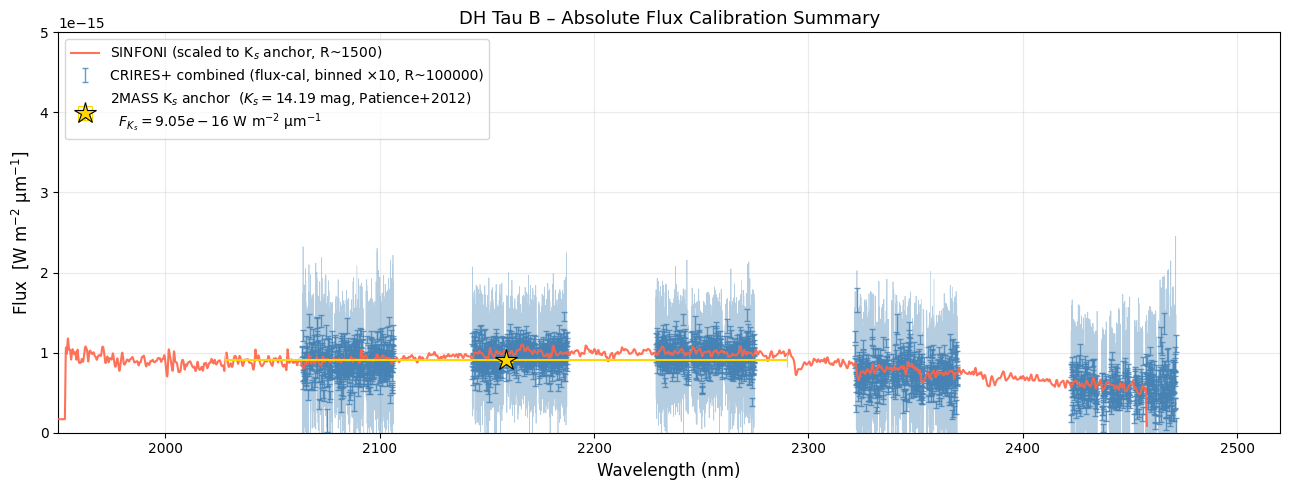

In [7]:
# ---- Summary plot: absolute flux calibration with photometric anchor ----

_K_eff_nm    = 2159.0
_K_bw_nm     = 131.0
_K_mag_err   = 0.02
_F_anchor    = _F_K_expected
_F_anchor_err = _F_anchor * np.log(10) / 2.5 * _K_mag_err

crires_wave_all = wave_data.flatten()
crires_flux_all = extracted_spectra_combined.flatten()
crires_err_all  = extracted_spectra_combined_err.flatten()

# Sort by wavelength before binning
_sort = np.argsort(crires_wave_all)
crires_wave_all = crires_wave_all[_sort]
crires_flux_all = crires_flux_all[_sort]
crires_err_all  = crires_err_all[_sort]

# Bin to ~10 pixels per bin with inverse-variance weighting
_bin_N  = 10
_N      = len(crires_wave_all)
_n_bins = _N // _bin_N
w_bin   = np.full(_n_bins, np.nan)
f_bin   = np.full(_n_bins, np.nan)
e_bin   = np.full(_n_bins, np.nan)

for _i in range(_n_bins):
    sl = slice(_i * _bin_N, (_i + 1) * _bin_N)
    _ok = np.isfinite(crires_flux_all[sl]) & np.isfinite(crires_err_all[sl]) & (crires_err_all[sl] > 0)
    if _ok.sum() < 3:
        w_bin[_i] = np.nanmean(crires_wave_all[sl])
        continue
    _wiv      = 1.0 / crires_err_all[sl][_ok]**2
    w_bin[_i] = np.mean(crires_wave_all[sl][_ok])
    f_bin[_i] = np.sum(_wiv * crires_flux_all[sl][_ok]) / np.sum(_wiv)
    e_bin[_i] = 1.0 / np.sqrt(np.sum(_wiv))

_bin_ok = np.isfinite(f_bin) & np.isfinite(e_bin)

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(crires_wave_all, crires_flux_all,
        color='steelblue', alpha=0.4, linewidth=0.5, zorder=2)

ax.errorbar(w_bin[_bin_ok], f_bin[_bin_ok], yerr=e_bin[_bin_ok],
            fmt='none', ecolor='steelblue', elinewidth=1.0, capsize=2, capthick=1.0,
            alpha=0.8, zorder=3, label='CRIRES+ combined (flux-cal, binned ×10, R~100000)')

ax.plot(sif_wave_v, sif_flux_v,
        color='tomato', alpha=0.9, linewidth=1.5, zorder=4,
        label='SINFONI (scaled to K$_s$ anchor, R~1500)')

ax.errorbar(_K_eff_nm, _F_anchor,
            xerr=_K_bw_nm, yerr=_F_anchor_err,
            fmt='*', color='gold', markeredgecolor='k', markeredgewidth=0.8,
            markersize=16, capsize=5, capthick=1.5, linewidth=1.5, zorder=10,
            label=(f'2MASS K$_s$ anchor  ($K_s = {_K_dhtaub}$ mag, Patience+2012)\n'
                   f'  $F_{{K_s}} = {_F_anchor:.2e}$ W m$^{{-2}}$ µm$^{{-1}}$'))

ax.set_xlim(1950, 2520)
ax.set_ylim(0, 5e-15)
ax.set_xlabel('Wavelength (nm)', fontsize=12)
ax.set_ylabel('Flux  [W m$^{-2}$ µm$^{-1}$]', fontsize=12)
ax.set_title('DH Tau B – Absolute Flux Calibration Summary', fontsize=13)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(workpath + night + '/flux_cal_summary.png', dpi=150, bbox_inches='tight')
plt.show()


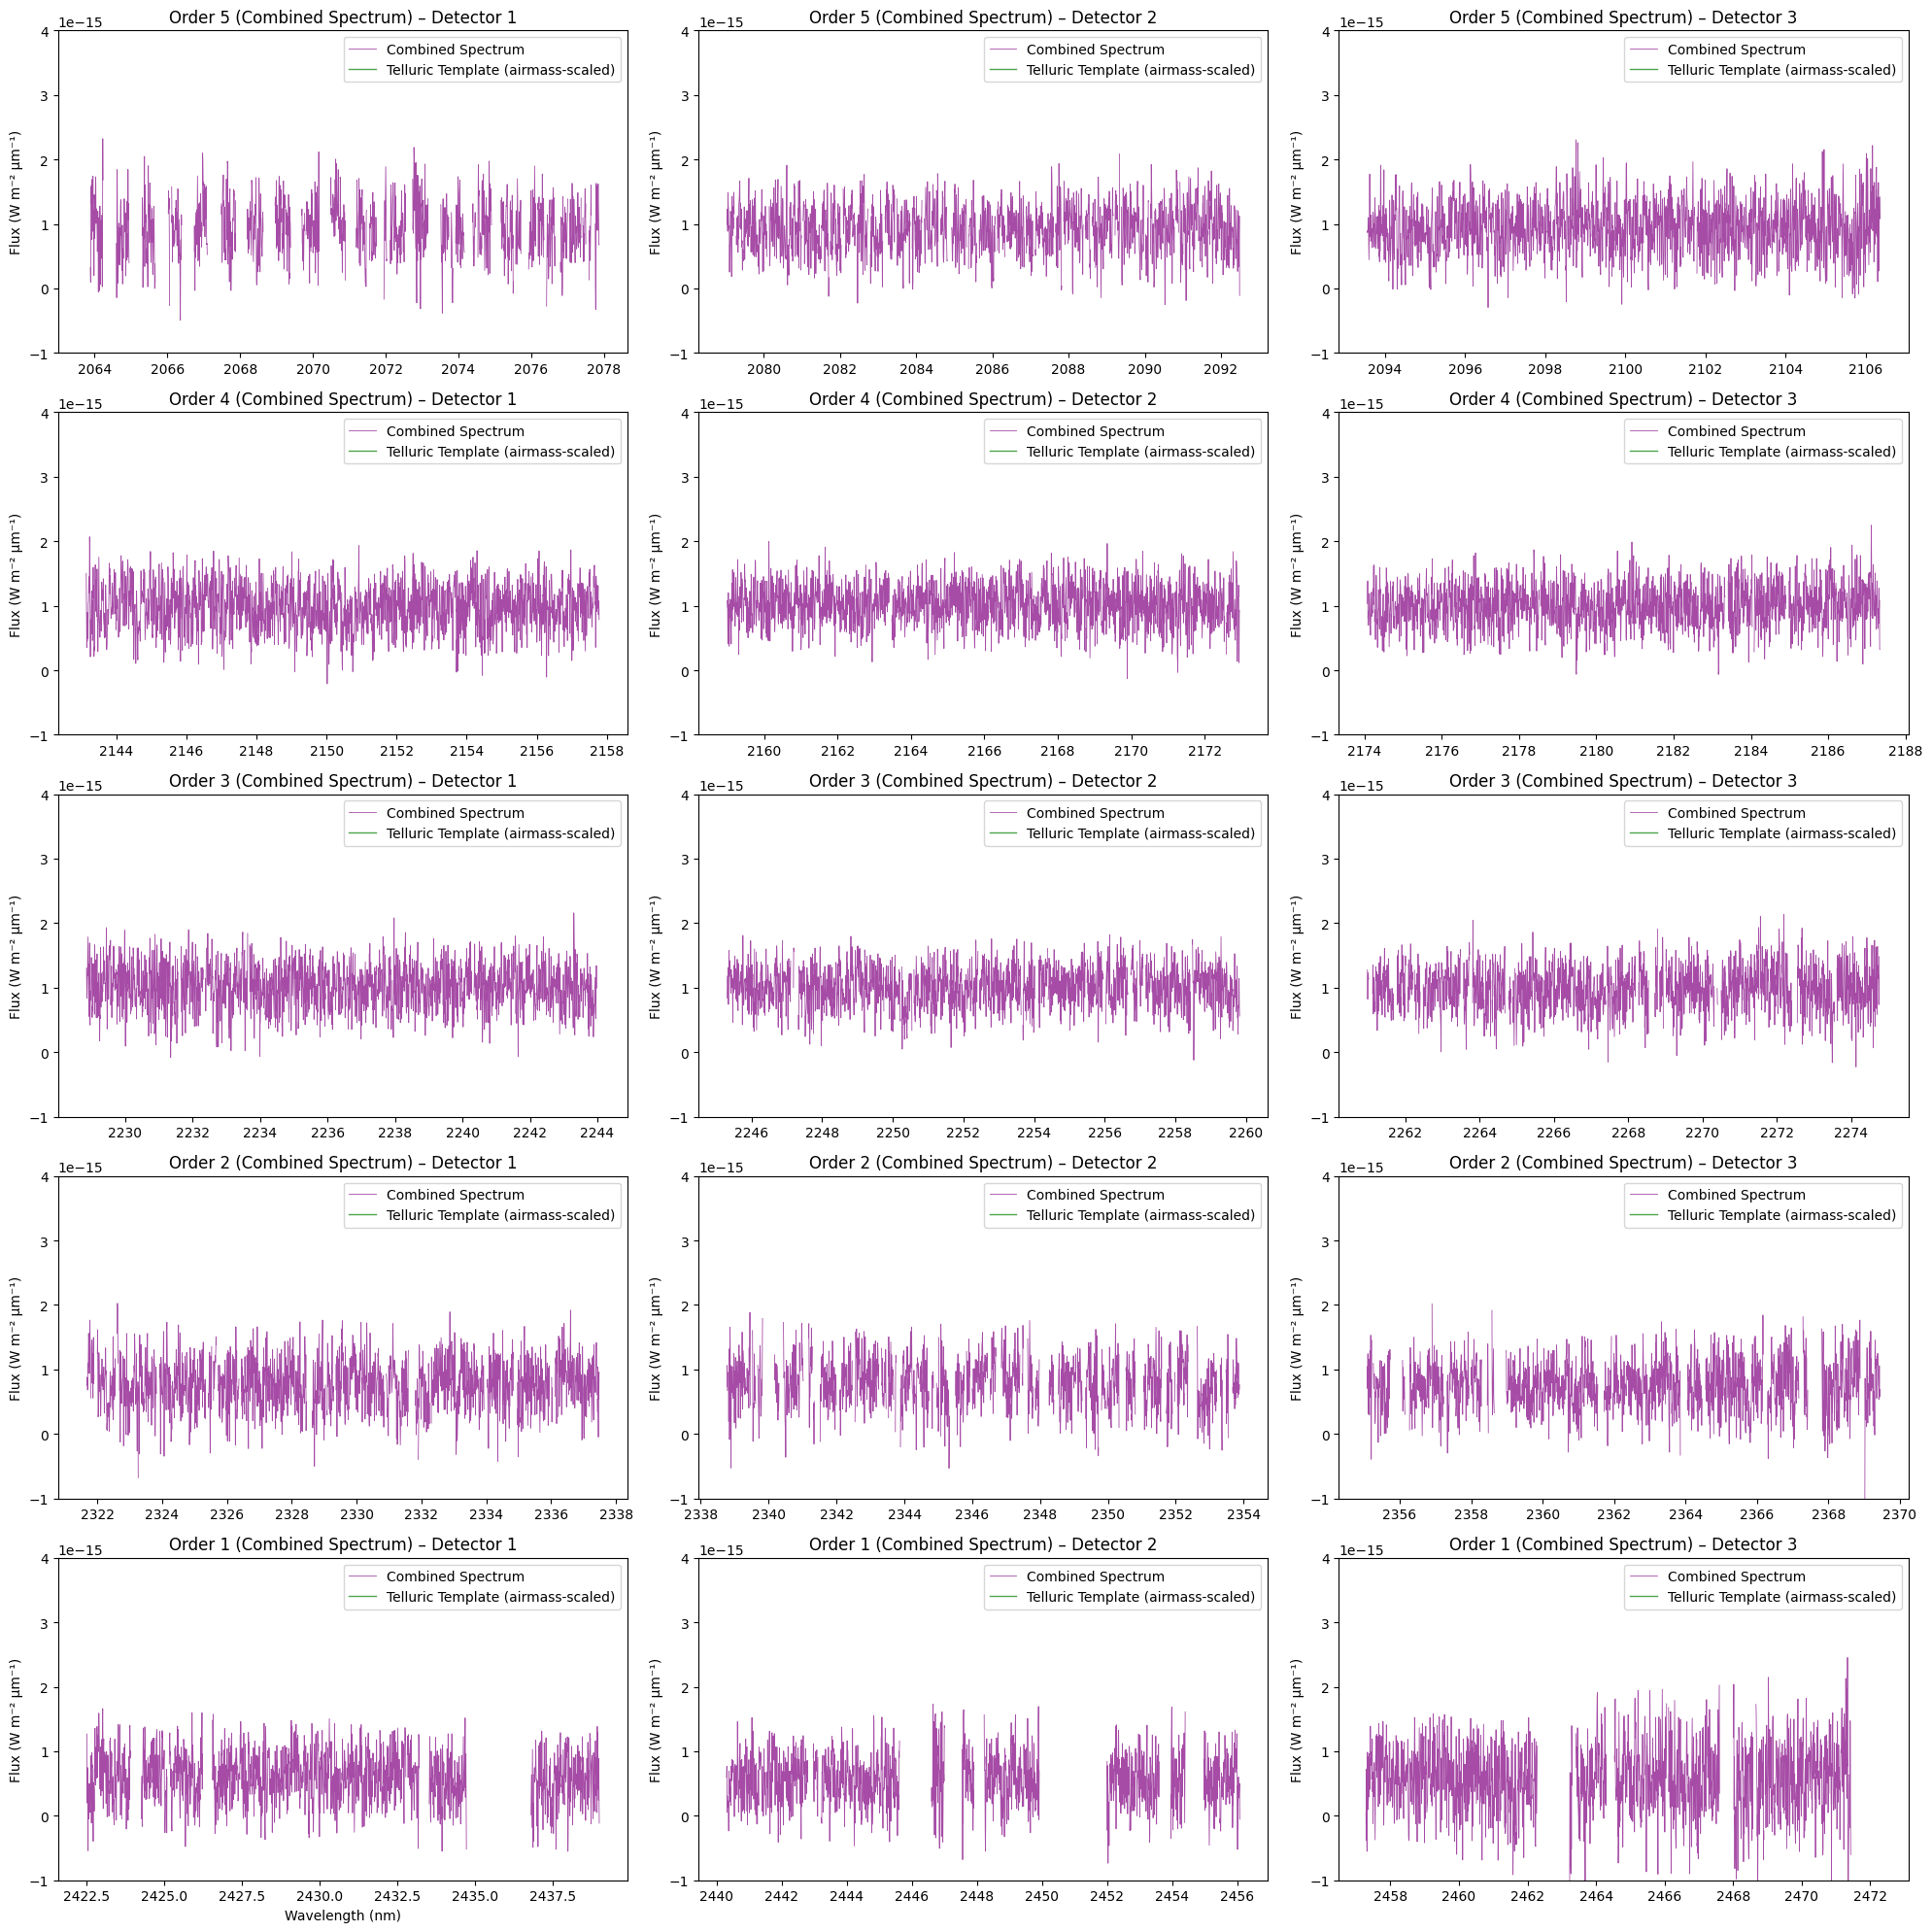

In [8]:
#again plot the combined extracted spectra for each order following the previous plotting code
fig, axs = plt.subplots(5,3, figsize=(20,20), sharex=False)
for order in range(5):
    index_plt = 4 - order

    for det in range(3):
        
        axs[index_plt, det].plot(wave_data[det, order, :].flatten(),
                                 extracted_spectra_combined[det, order, :].flatten(),
                                 label='Combined Spectrum', color='purple', alpha=0.7, linewidth=0.6)
        
        '''
        axs[index_plt, det].errorbar(wave_data[det, order, :].flatten(),
                                     extracted_spectra_combined[det, order, :].flatten(),
                                     yerr=extracted_spectra_combined_err[det, order, :].flatten(),
                                     fmt='o', color='gray', alpha=0.5, markersize=0.1,
                                     label='Combined Spectrum Error')
        '''

        axs[index_plt, det].plot(telluric_template[det, order, :]['lambda'].flatten() * 1e3,
                                 telluric_mtrans[det, order, :].flatten(),
                                 label='Telluric Template (airmass-scaled)', color='green', alpha=0.7, linewidth=1)

        axs[index_plt, det].set_ylabel('Flux (W m⁻² µm⁻¹)')
        axs[index_plt, det].set_title(f'Order {order+1} (Combined Spectrum) – Detector {det+1}')
        axs[index_plt, det].legend()

        axs[index_plt, det].set_ylim(-1e-15, 4e-15)
    
axs[4, 0].set_xlabel('Wavelength (nm)')
plt.tight_layout()
plt.show()

## 2.2 Run SNR check 

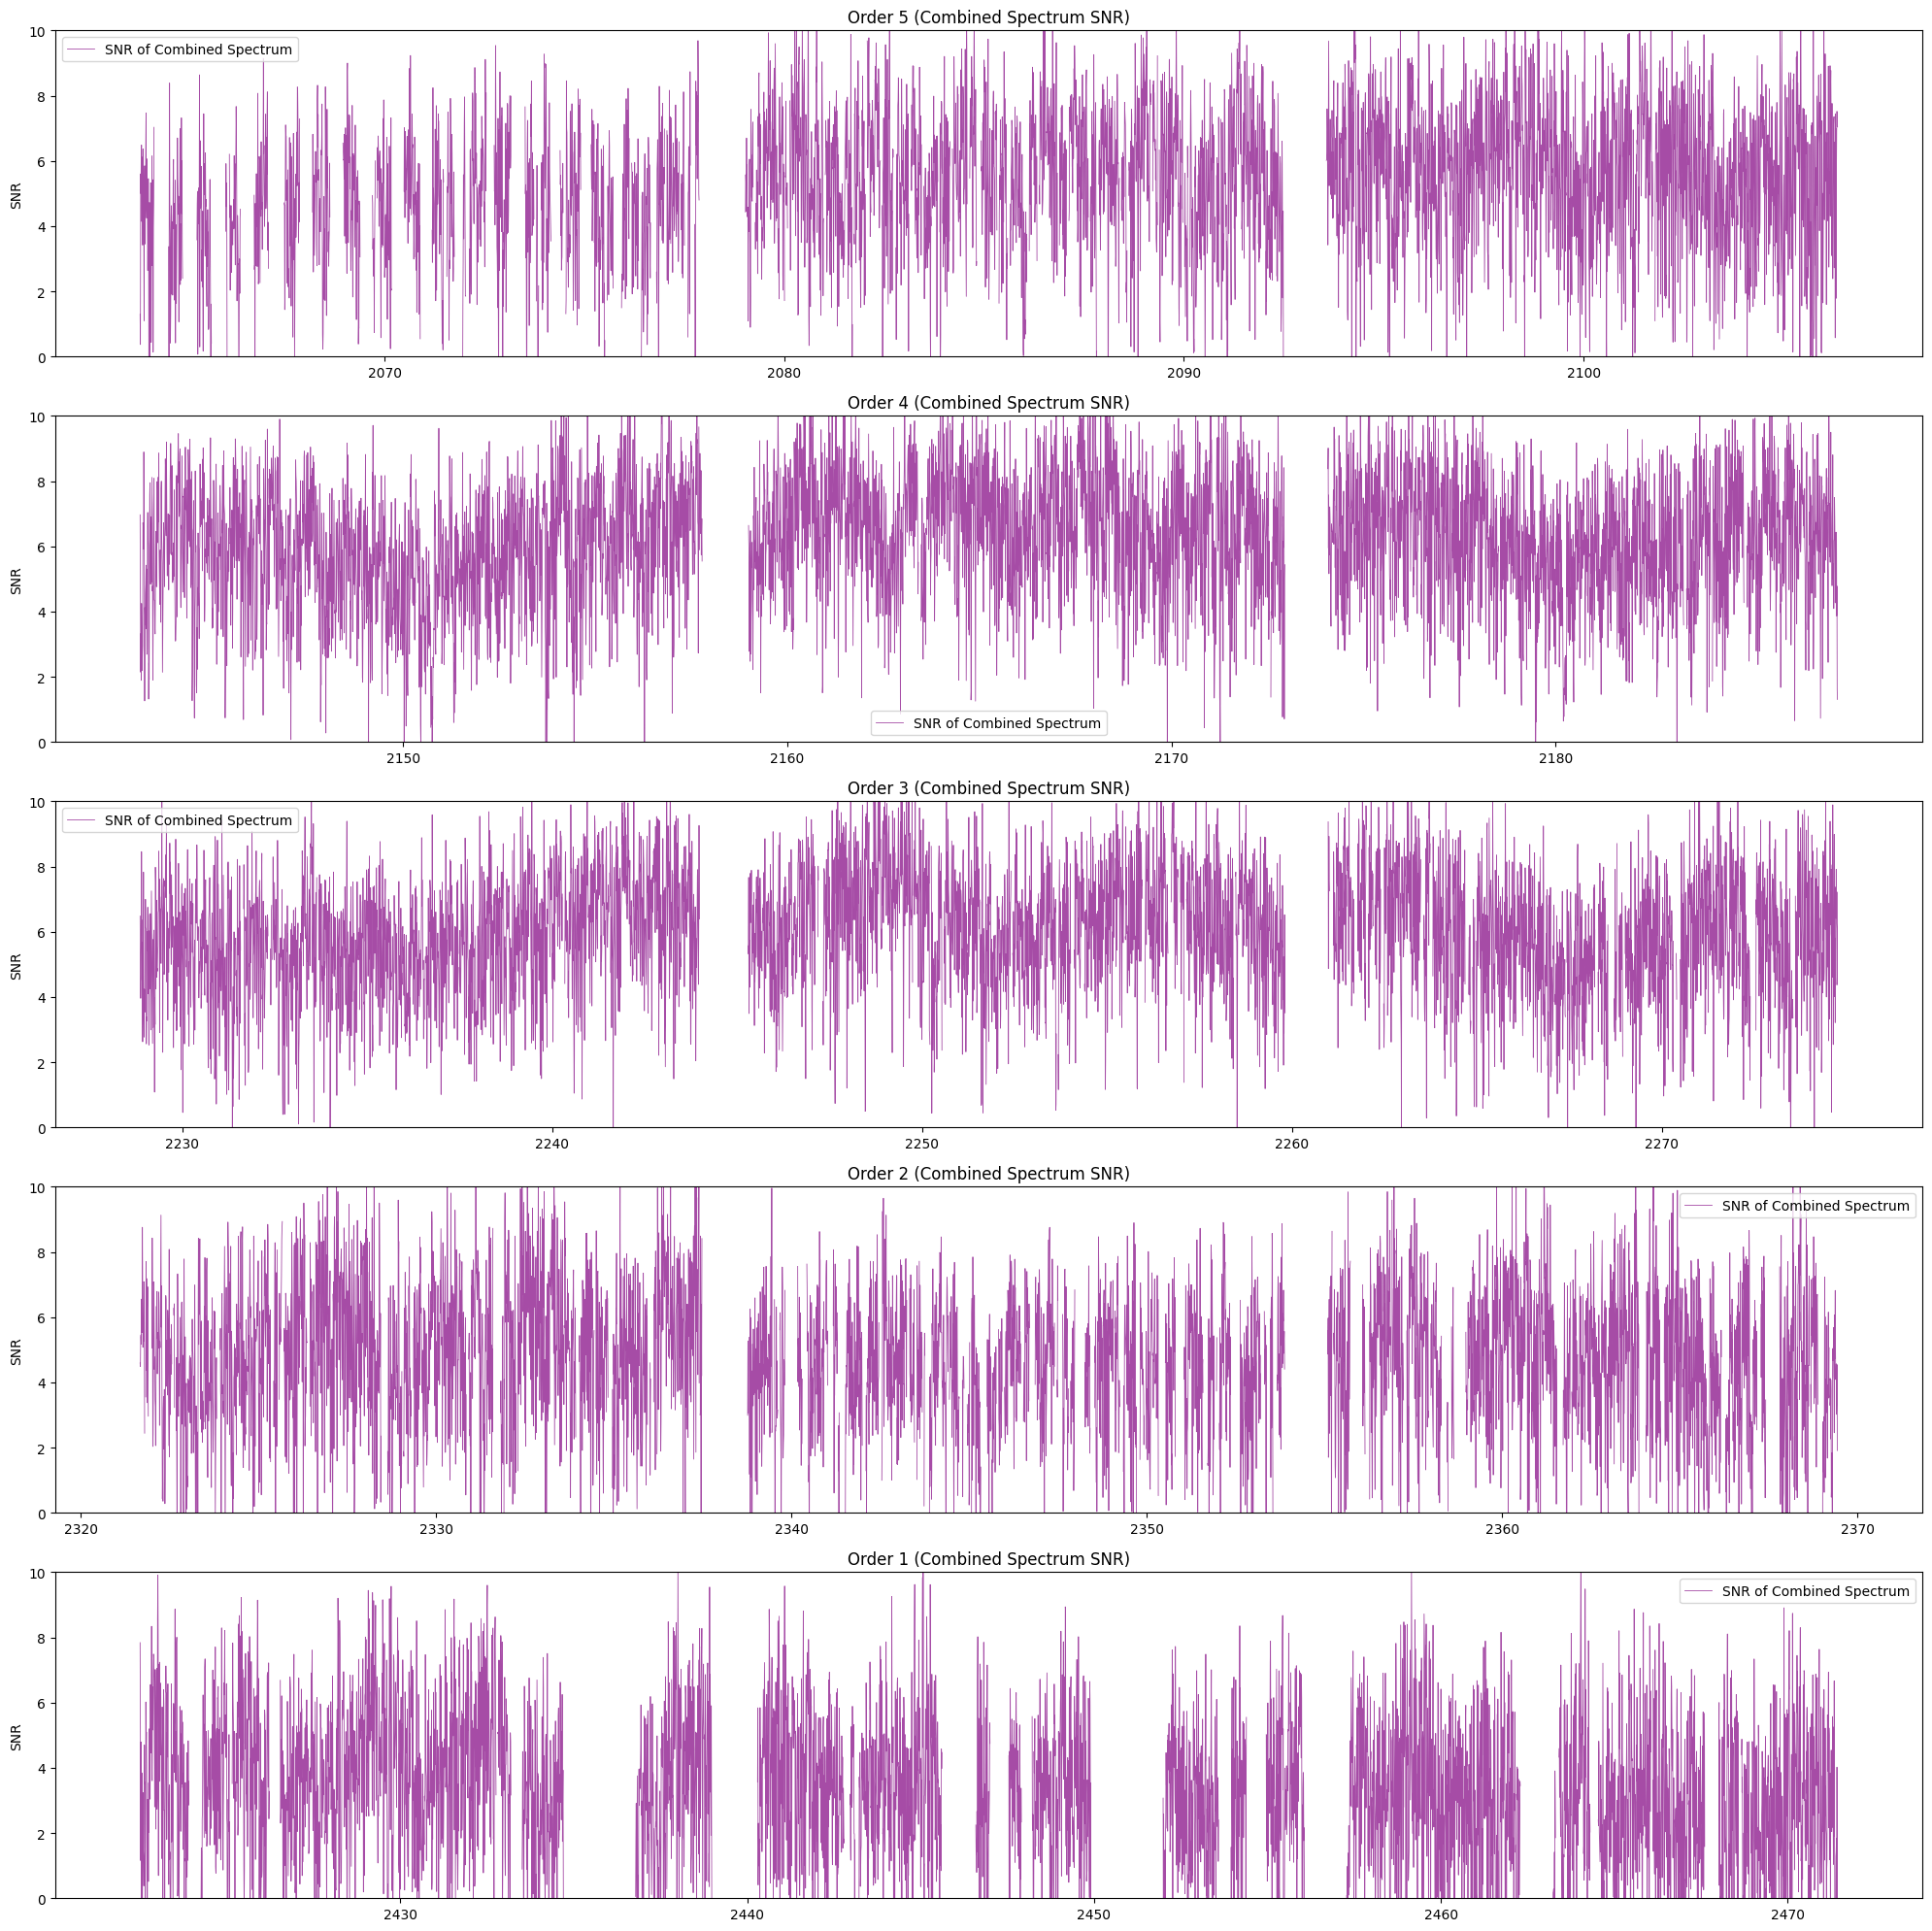

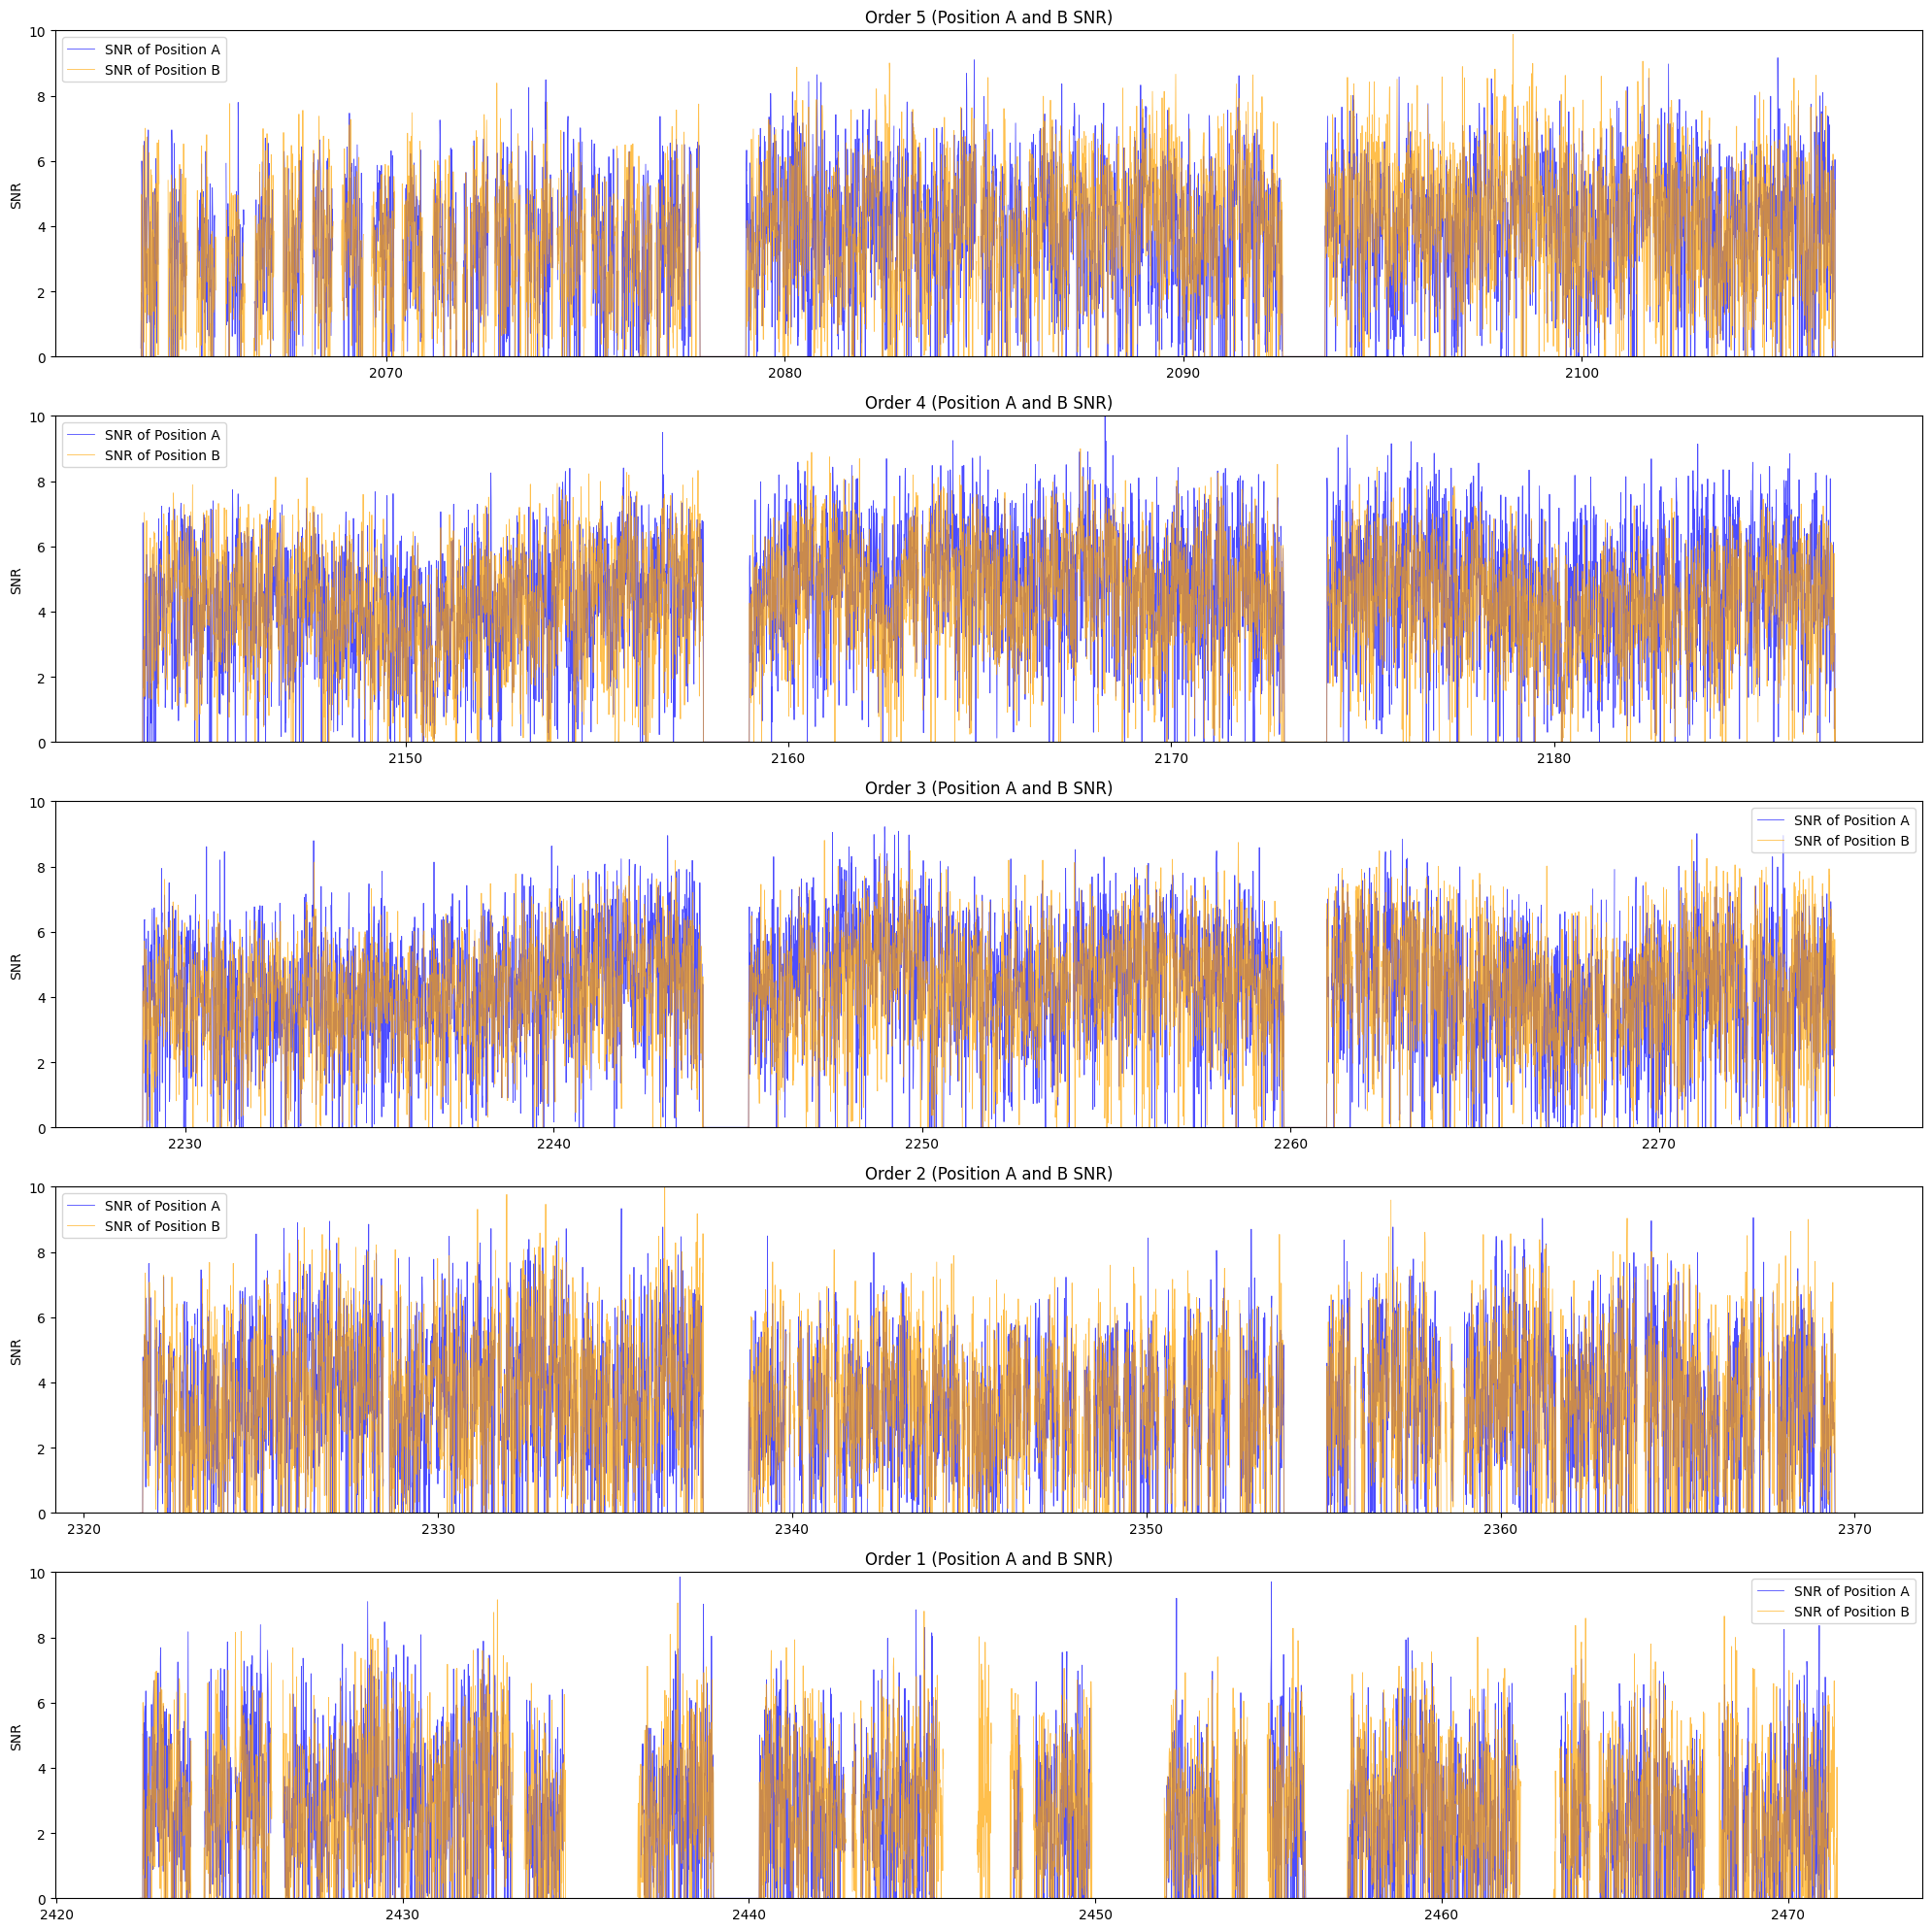

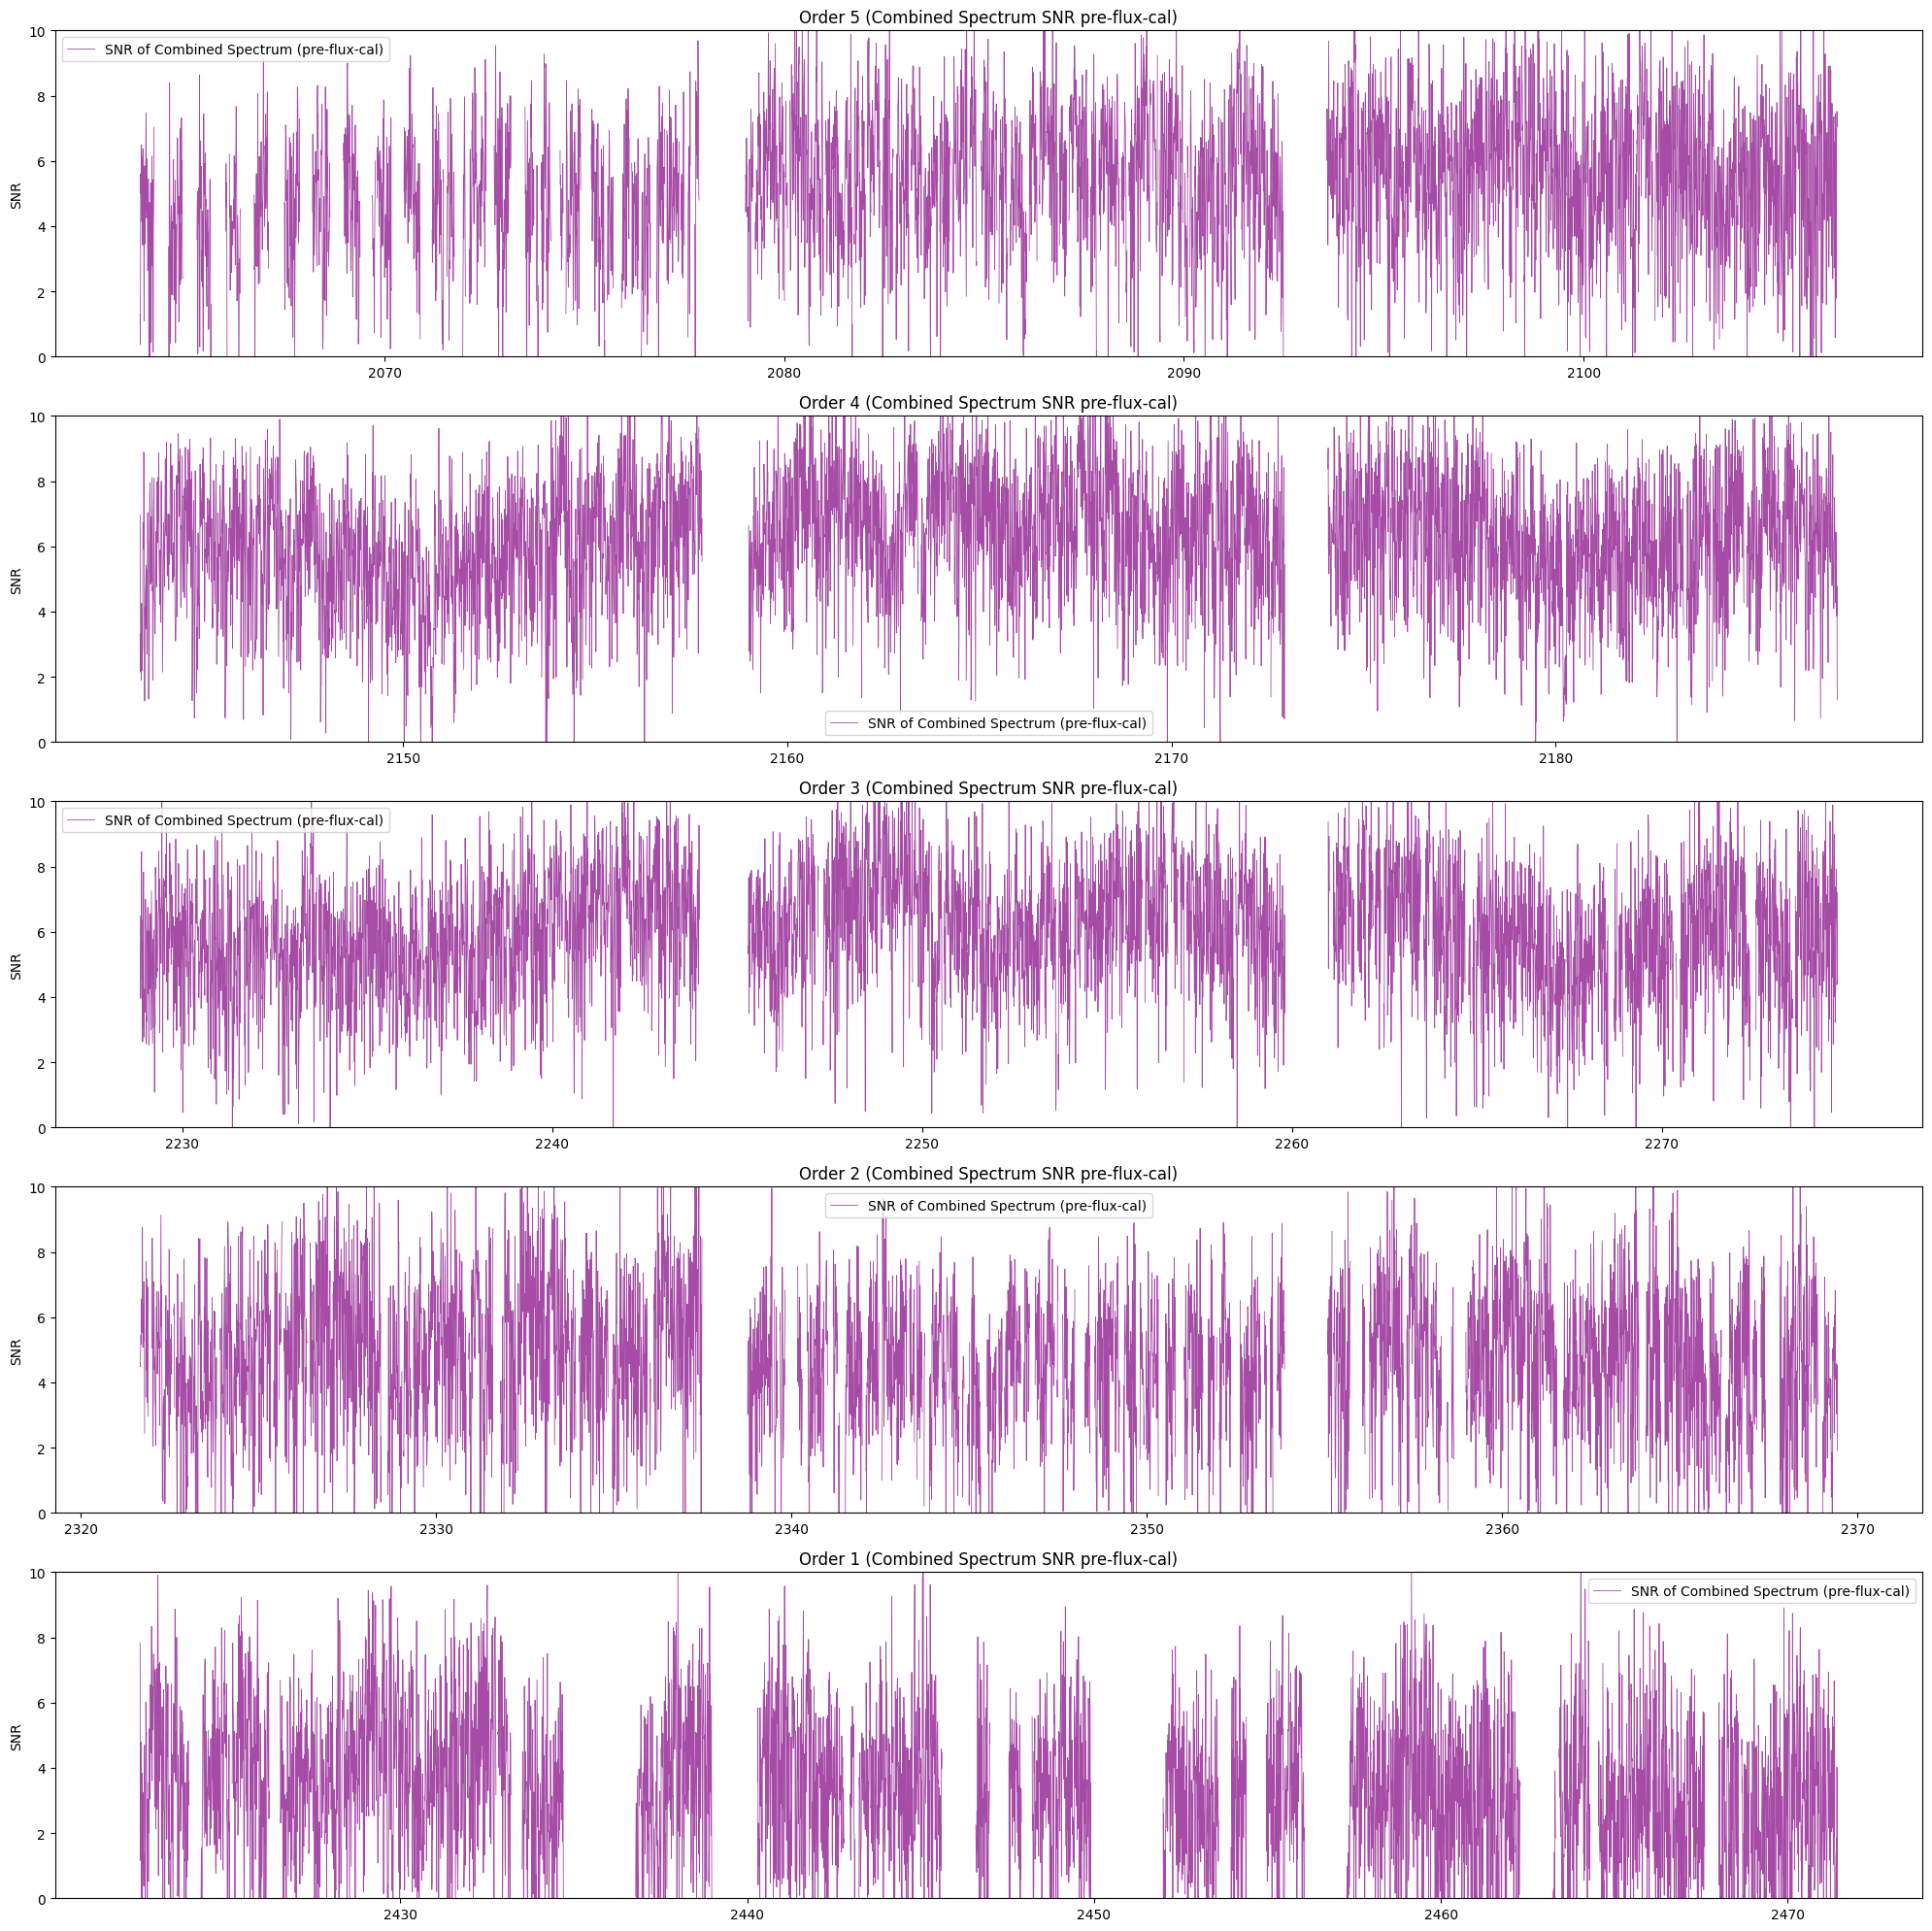

In [9]:
#Calculate the SNR of the combined spectrum for each order and plot it
extracted_spectra_combined = np.load(workpath + '/' + night + '/extracted_spectra_combined_sigmaclipper.npy')
extracted_spectra_combined_err = np.load(workpath + '/' + night + '/extracted_spectra_combined_err_sigmaclipper.npy')

wave_hdu = fits.open(workpath + night + '/cal/WLEN_K2166_V_DH_Tau_A+B_center.fits')
wave_data = np.array(wave_hdu[1].data)[:, 0:5, ]  # (3, 5, 2048)

fig, axs = plt.subplots(5, 1, figsize=(20, 20), sharex=False)
for order in range(5):
    index_plt = 4 - order

    # Formal per-pixel SNR from propagated error array
    snr = extracted_spectra_combined[:, order, :].flatten() / extracted_spectra_combined_err[:, order, :].flatten()

    axs[index_plt].plot(wave_data[:,order,:].flatten(), snr, label='SNR of Combined Spectrum', color='purple', alpha=0.7, linewidth=0.6)

    axs[index_plt].set_ylabel('SNR')
    axs[index_plt].set_title(f'Order {order+1} (Combined Spectrum SNR)')
    axs[index_plt].legend()

    axs[index_plt].set_ylim(0, 10)

plt.tight_layout()
plt.show()

#Calulate the SNR for each nodding position and plot it (empirical — error arrays not in scope here)
extracted_spectra_A = np.load(workpath+ '/' + night+'/extracted_spectra_position_A_sigmaclipper_0417.npy')
extracted_spectra_B = np.load(workpath+ '/' + night+'/extracted_spectra_position_B_sigmaclipper_0417.npy')

extracted_spectra_A_err = np.load(workpath + '/' + night+'/extracted_spectra_position_A_err_0417.npy')
extracted_spectra_B_err = np.load(workpath + '/' + night+'/extracted_spectra_position_B_err_0417.npy')

fig, axs = plt.subplots(5, 1, figsize=(20, 20), sharex=False)
for order in range(5):
    index_plt = 4 - order

    snr_A = extracted_spectra_A[:,order,:].flatten() / extracted_spectra_A_err[:,order,:].flatten()
    snr_B = extracted_spectra_B[:,order,:].flatten() / extracted_spectra_B_err[:,order,:].flatten()

    axs[index_plt].plot(wave_data[:,order,:].flatten(), snr_A, label='SNR of Position A', color='blue', alpha=0.7, linewidth=0.6)
    axs[index_plt].plot(wave_data[:,order,:].flatten(), snr_B, label='SNR of Position B', color='orange', alpha=0.7, linewidth=0.6)

    axs[index_plt].set_ylabel('SNR')
    axs[index_plt].set_title(f'Order {order+1} (Position A and B SNR)')
    axs[index_plt].legend()

    axs[index_plt].set_ylim(0, 10)

plt.tight_layout()  
plt.show()

#Calulate the SNR for the combined spectra before flux calibration and plot it
extracted_spectra_combined_raw = np.load(workpath + '/' + night + '/extracted_spectra_combined_sigmaclipper.npy')
extracted_spectra_combined_raw_err = np.load(workpath + '/' + night + '/extracted_spectra_combined_err_sigmaclipper.npy')

fig, axs = plt.subplots(5, 1, figsize=(20, 20), sharex=False)
for order in range(5):
    index_plt = 4 - order

    # Formal per-pixel SNR from propagated error array
    snr_combined_raw = extracted_spectra_combined_raw[:, order, :].flatten() / extracted_spectra_combined_raw_err[:, order, :].flatten()

    axs[index_plt].plot(wave_data[:,order,:].flatten(), snr_combined_raw, label='SNR of Combined Spectrum (pre-flux-cal)', color='purple', alpha=0.7, linewidth=0.6)

    axs[index_plt].set_ylabel('SNR')
    axs[index_plt].set_title(f'Order {order+1} (Combined Spectrum SNR pre-flux-cal)')
    axs[index_plt].legend()

    axs[index_plt].set_ylim(0, 10)

plt.tight_layout()
plt.show()


# 3. Run simple Cross Correlation test to obtain the observed RV and CC SNR 

CO template: 110013 points, wavelength 1421.5 - 2500.0 nm
Obs cube shape  : (3, 5, 1, 2048)
Wave grid shape : (3, 5, 2048)
RV lag          : -100 to 100 km/s  (201 steps)


/var/tmp/peng/ipykernel_2027436/286222398.py:83: RuntimeWarning: All-NaN slice encountered
  medFlux[iDet, iOrder, :] = np.nanmedian(self.cube[iDet, iOrder, :, :], axis=0)



Peak CCF SNR = 11.14  at  RV = 31.0 km/s

Auto CCF Peak SNR = 101.52  at  RV = 0.0 km/s


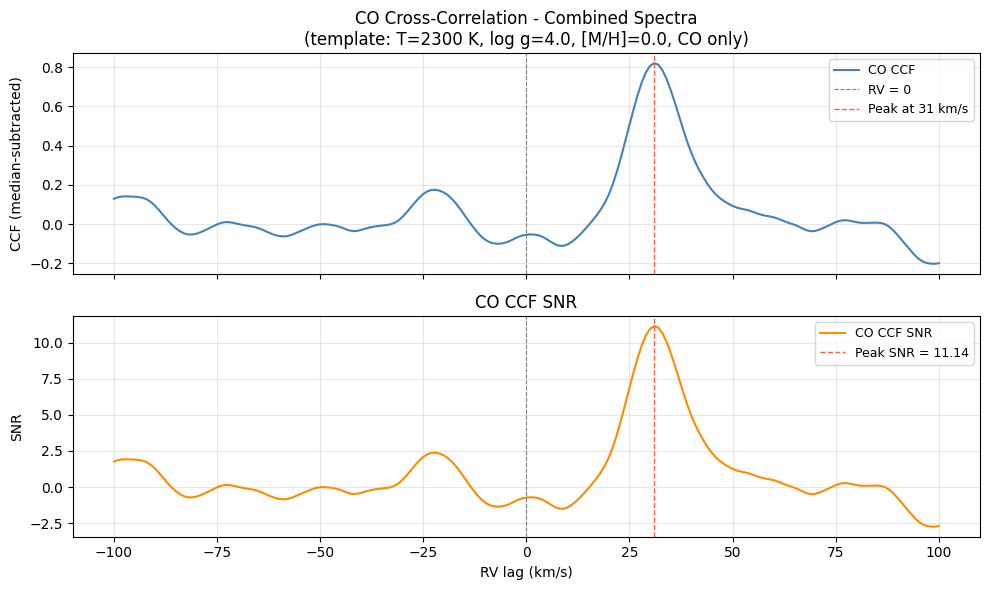

In [10]:
# ============================================================
# CO Cross-Correlation on Combined Spectra
# ============================================================
from scipy import interpolate

# ---- processor_cross_correlation class (from cooking_subtraction.ipynb Cell 4) ----
#load barycentric corrected wavelength grid
#wave_data = np.load(workpath +'/' + night + '/barycentric_wavelengths_night1.npy')  # shape (3, 5, 2048)

class processor_cross_correlation:
    def __init__(self, wMod, fMod, wlen, cube, nOrder, n_spatial, nDet):
        """
        wMod, fMod : 1D model wavelength and flux (same length)
        wlen : observed wavelength grid with shape (nDet, nOrder, nPix)
        cube : observed cube shape (nDet, nOrder, n_spatial, nPix)
        """
        self.wMod = wMod
        self.fMod = fMod
        self.wlen = wlen
        self.cube = cube
        self.n_spatial = n_spatial
        self.nOrder = nOrder
        self.nDet = nDet

    def xcorr(self, f, g):
        """
        Normalized cross-correlation between 1D arrays f and g.
        Returns NaN if variance is zero.
        """
        f = np.asarray(f, dtype=float)
        g = np.asarray(g, dtype=float)
        nx = len(f)
        if nx == 0:
            return np.nan
        I = np.ones(nx)
        f_mean_sub = f - (np.dot(f, I) / nx)
        g_mean_sub = g - (np.dot(g, I) / nx)
        R    = np.dot(f_mean_sub, g_mean_sub) / nx
        varf = np.dot(f_mean_sub, f_mean_sub) / nx
        varg = np.dot(g_mean_sub, g_mean_sub) / nx
        denom = np.sqrt(varf * varg)
        if denom == 0 or np.isnan(denom):
            return np.nan
        return R / denom

    def get_cc_grid(self, rvlag, ncc):
        """
        Compute CCF cube with shape (nDet, nOrder, n_spatial, ncc).
        """
        ccf = np.zeros((self.nDet, self.nOrder, self.n_spatial, ncc))
        coef_spline = interpolate.splrep(self.wMod, self.fMod, s=0.0)

        for irv, rv in enumerate(rvlag):
            beta   = rv / 2.998e5
            wShift = self.wlen * np.sqrt((1.0 - beta) / (1.0 + beta))
            intMod = interpolate.splev(wShift, coef_spline, der=0)  # (nDet, nOrder, nPix)

            for iDet in range(self.nDet):
                for iOrder in range(self.nOrder):
                    for iObs in range(self.n_spatial):
                        obs       = self.cube[iDet, iOrder, iObs, :]
                        model_row = intMod[iDet, iOrder, :]
                        mask = np.isfinite(obs) & np.isfinite(model_row)
                        if np.sum(mask) < 5:
                            ccf[iDet, iOrder, iObs, irv] = np.nan
                        else:
                            ccf[iDet, iOrder, iObs, irv] = self.xcorr(obs[mask], model_row[mask])

        self.rvlag = rvlag
        self.ncc   = ncc
        return ccf

    def ccf_tot(self, rvlag, ncc, plot=True, subtract_continuum='med_flux',
                normalization='median subtracted', v_sys=None, clean_grids=None,
                po=None, central_pix=None, spatial_pix=None):
        """
        Returns ccf_Sum and ccf_SNR, each shape (n_spatial, ncc),
        summed across detectors and orders.
        """
        medFlux = np.zeros((self.nDet, self.nOrder, self.wlen.shape[-1]))
        for iDet in range(self.nDet):
            for iOrder in range(self.nOrder):
                medFlux[iDet, iOrder, :] = np.nanmedian(self.cube[iDet, iOrder, :, :], axis=0)

        ccfWeight = np.sum(medFlux, axis=(0, 1))
        if np.nansum(ccfWeight) != 0:
            ccfWeight = ccfWeight / np.nansum(ccfWeight)

        ccf     = self.get_cc_grid(rvlag, ncc)      # (nDet, nOrder, n_spatial, ncc)
        ccf_Sum = np.nansum(ccf, axis=(0, 1))       # (n_spatial, ncc)

        if normalization == 'median':
            denom = np.nanmedian(ccf_Sum)
            if denom != 0:
                ccf_Sum = (ccf_Sum - denom) / denom
        elif normalization == 'max':
            mval = np.nanmax(ccf_Sum)
            if mval != 0:
                ccf_Sum = ccf_Sum / mval
        elif normalization == 'median subtracted':
            for iObs in range(self.n_spatial):
                med = np.nanmedian(ccf_Sum[iObs, :])
                ccf_Sum[iObs, :] -= med

        if plot:
            plt.figure(figsize=(10, 4))
            plt.imshow(ccf_Sum, aspect='auto', origin='lower',
                       extent=(rvlag[0], rvlag[-1], 0, self.n_spatial))
            plt.colorbar(label='CCF')
            plt.xlabel('RV lag (km/s)')
            plt.ylabel('Spatial index')
            plt.title('CCF map')
            if central_pix is not None:
                plt.hlines(y=central_pix, xmin=rvlag[0], xmax=rvlag[-1],
                           ls='--', colors='lightgray')
            if v_sys is not None:
                plt.vlines(x=v_sys, ymin=0, ymax=(self.n_spatial - 1),
                           ls='--', colors='lightgray')
            plt.tight_layout()
            plt.show()

        if clean_grids is None:
            std_ccf = np.nanstd(ccf_Sum)
        else:
            g0, g1 = int(clean_grids[0][0]), int(clean_grids[0][1])
            g2, g3 = int(clean_grids[1][0]), int(clean_grids[1][1])
            ccf_clean_map = np.concatenate((ccf_Sum[:, g0:g1], ccf_Sum[:, g2:g3]), axis=1)
            std_ccf = np.nanstd(ccf_clean_map)

        ccf_SNR = np.full_like(ccf_Sum, np.nan)
        if std_ccf != 0:
            ccf_SNR = ccf_Sum / std_ccf

        if plot:
            plt.figure(figsize=(10, 4))
            plt.imshow(ccf_SNR, aspect='auto', origin='lower',
                       extent=(rvlag[0], rvlag[-1], 0, self.n_spatial))
            plt.colorbar(label='SNR')
            plt.xlabel('RV lag (km/s)')
            plt.ylabel('Spatial index')
            plt.title('CCF SNR map')
            if central_pix is not None:
                plt.hlines(y=central_pix, xmin=rvlag[0], xmax=rvlag[-1],
                           ls='--', colors='lightgray')
            if v_sys is not None:
                plt.vlines(x=v_sys, ymin=0, ymax=(self.n_spatial - 1),
                           ls='--', colors='lightgray')
            plt.tight_layout()
            plt.show()

        return (ccf_Sum, ccf_SNR)


# ---- Load CO template spectrum ----
# File layout: shape (2, N) where row 0 = wavelength [m], row 1 = flux
co_template_path = workpath + '/spectra_input/planet_2300_4.0_-0.0_0_co_only.dat'
co_template  = np.loadtxt(co_template_path)
ccf_model_w  = co_template[0]   # wavelength in metres
ccf_model_f  = co_template[1]   # flux (arbitrary units)

# Sort ascending in wavelength (required by splrep)
sort_idx    = np.argsort(ccf_model_w)
ccf_model_w = ccf_model_w[sort_idx]
ccf_model_f = ccf_model_f[sort_idx]

print(f'CO template: {len(ccf_model_w)} points, '
      f'wavelength {ccf_model_w.min()*1e9:.1f} - {ccf_model_w.max()*1e9:.1f} nm')

# ---- RV lag grid: -100 to +100 km/s, step 1 km/s ----
RVlag = np.arange(-100, 101, 1)   # 201 points
ncc   = len(RVlag)

# ---- Prepare the data cube ----
# extracted_spectra_combined shape: (nDet=3, nOrder=5, nPix=2048)
# Add singleton spatial axis -> (nDet, nOrder, n_spatial=1, nPix)
nDet, nOrder, nPix = extracted_spectra_combined.shape
cube_combined = extracted_spectra_combined[:, :, np.newaxis, :]  # (3, 5, 1, 2048)

print(f'Obs cube shape  : {cube_combined.shape}')
print(f'Wave grid shape : {wave_data.shape}')
print(f'RV lag          : {RVlag[0]} to {RVlag[-1]} km/s  ({ncc} steps)')

# ---- Instantiate cross-correlator ----
process_cc_combined = processor_cross_correlation(
    wMod      = ccf_model_w * 1e9,   # metres -> nm to match wave_data
    fMod      = ccf_model_f,
    wlen      = wave_data,            # (nDet, nOrder, nPix) in nm
    cube      = cube_combined,        # (nDet, nOrder, 1, nPix)
    nOrder    = nOrder,
    nDet      = nDet,
    n_spatial = 1
)

# ---- Run cross-correlation ----
ccf_sum, ccf_snr = process_cc_combined.ccf_tot(
    rvlag         = RVlag,
    ncc           = ncc,
    plot          = False,
    normalization = 'median subtracted',
    clean_grids = [(0, 50), (150, 200)]
)

# ccf_sum / ccf_snr shape (1, 201) -> squeeze to 1D
ccf_1d     = ccf_sum[0, :]
ccf_snr_1d = ccf_snr[0, :]

peak_rv  = RVlag[np.nanargmax(ccf_snr_1d)]
peak_snr = np.nanmax(ccf_snr_1d)
print(f'\nPeak CCF SNR = {peak_snr:.2f}  at  RV = {peak_rv:.1f} km/s')


#---- Run auto corss-correlation -----

#using spline interpolation and reshape the model flux to (nDet, nOrder, 1, nPix) to match the cube shape
ccf_model_f_int = np.zeros((nDet, nOrder, nPix))
coef_spline = interpolate.splrep(ccf_model_w * 1e9, ccf_model_f, s=0.0)  # spline coefficients for the model
splev = interpolate.splev  # ensure local name used below is defined
for iDet in range(nDet):
    for iOrder in range(nOrder):
        ccf_model_f_int[iDet, iOrder, :] = splev(wave_data[iDet, iOrder, :], coef_spline, der=0)
        


ccf_model_f_reshaped = ccf_model_f_int[:, :, np.newaxis, :]  # (nDet, nOrder, 1, nPix)

process_cc_auto = processor_cross_correlation(
    wMod      = ccf_model_w * 1e9,   # metres -> nm to match wave_data
    fMod      = ccf_model_f,
    wlen      = wave_data,            # (nDet, nOrder, nPix) in nm
    cube      = ccf_model_f_reshaped,                  # (nDet, nOrder, 1, nPix)
    nOrder    = nOrder,
    nDet      = nDet,
    n_spatial = 1
)

ccf_auto, ccf_auto_snr = process_cc_auto.ccf_tot(
    rvlag         = RVlag,  
    ncc           = ncc,
    plot          = False,
    normalization = 'median subtracted',
    clean_grids = [(0, 50), (150, 200)]

)

ccf_auto_1d = ccf_auto[0, :]
ccf_auto_snr_1d = ccf_auto_snr[0, :]

peak_rv_auto = RVlag[np.nanargmax(ccf_auto_snr_1d)]
peak_snr_auto = np.nanmax(ccf_auto_snr_1d)
print(f'\nAuto CCF Peak SNR = {peak_snr_auto:.2f}  at  RV = {peak_rv_auto:.1f} km/s')

# ---- Plot results ----
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(RVlag, ccf_1d, color='steelblue', linewidth=1.5, label='CO CCF')
axes[0].axvline(0,       color='gray',   linestyle='--', linewidth=0.8, label='RV = 0')
axes[0].axvline(peak_rv, color='tomato', linestyle='--', linewidth=1.0,
                label=f'Peak at {peak_rv:.0f} km/s')
#axes[0].plot(RVlag, ccf_auto_1d, color='darkorange', linewidth=1.5, label='Auto CCF')


axes[0].set_ylabel('CCF (median-subtracted)')
axes[0].set_title('CO Cross-Correlation - Combined Spectra\n'
                  '(template: T=2300 K, log g=4.0, [M/H]=0.0, CO only)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(RVlag, ccf_snr_1d, color='darkorange', linewidth=1.5, label='CO CCF SNR')
axes[1].axvline(0,       color='gray',   linestyle='--', linewidth=0.8)
axes[1].axvline(peak_rv, color='tomato', linestyle='--', linewidth=1.0,
                label=f'Peak SNR = {peak_snr:.2f}')
axes[1].set_xlabel('RV lag (km/s)')
axes[1].set_ylabel('SNR')
axes[1].set_title('CO CCF SNR')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(workpath + night + '/co_ccf_combined_spectra.png', dpi=150, bbox_inches='tight')
plt.show()


CO template: 110013 points, wavelength 1421.5 - 2500.0 nm
Obs cube shape  : (3, 5, 1, 2048)
Wave grid shape : (3, 5, 2048)
RV lag          : -100 to 100 km/s  (201 steps)


/var/tmp/peng/ipykernel_2027436/286222398.py:83: RuntimeWarning: All-NaN slice encountered
  medFlux[iDet, iOrder, :] = np.nanmedian(self.cube[iDet, iOrder, :, :], axis=0)



Peak CCF SNR = 20.12  at  RV = 32.0 km/s

Auto CCF Peak SNR = 62.61  at  RV = 0.0 km/s


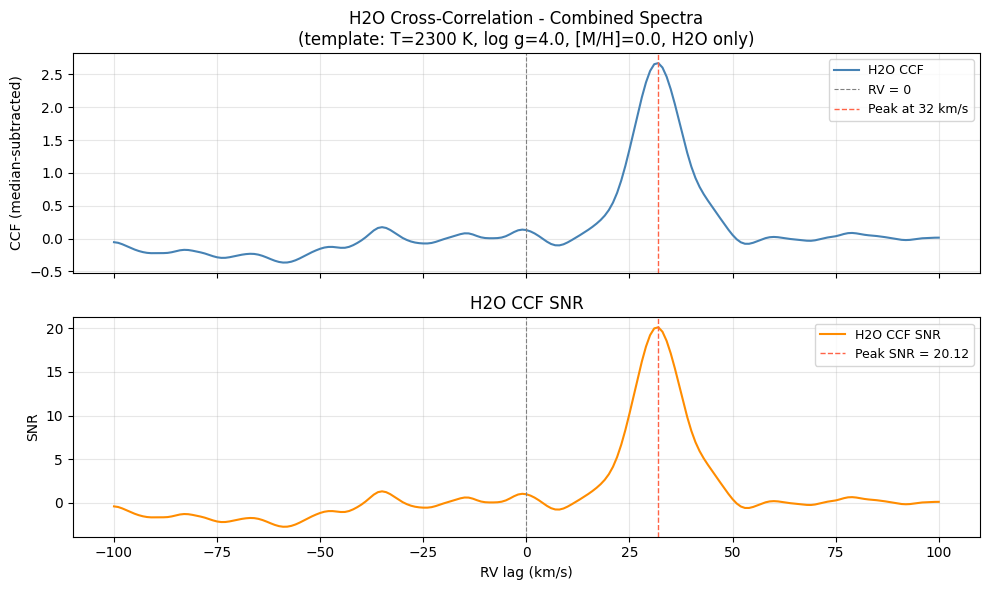

In [11]:
#----- Load H2O template spectrum ----
h2o_template_path = workpath + '/spectra_input/planet_2300_4.0_-0.0_0_h2o_pokazatel_only.dat'
h2o_template = np.loadtxt(h2o_template_path)
ccf_model_w = h2o_template[0]
ccf_model_f = h2o_template[1]  

# Sort ascending in wavelength (required by splrep)
sort_idx    = np.argsort(ccf_model_w)
ccf_model_w = ccf_model_w[sort_idx]
ccf_model_f = ccf_model_f[sort_idx]

print(f'CO template: {len(ccf_model_w)} points, '
      f'wavelength {ccf_model_w.min()*1e9:.1f} - {ccf_model_w.max()*1e9:.1f} nm')

# ---- RV lag grid: -100 to +100 km/s, step 1 km/s ----
RVlag = np.arange(-100, 101, 1)   # 201 points
ncc   = len(RVlag)

# ---- Prepare the data cube ----
# extracted_spectra_combined shape: (nDet=3, nOrder=5, nPix=2048)
# Add singleton spatial axis -> (nDet, nOrder, n_spatial=1, nPix)
nDet, nOrder, nPix = extracted_spectra_combined.shape
cube_combined = extracted_spectra_combined[:, :, np.newaxis, :]  # (3, 5, 1, 2048)

print(f'Obs cube shape  : {cube_combined.shape}')
print(f'Wave grid shape : {wave_data.shape}')
print(f'RV lag          : {RVlag[0]} to {RVlag[-1]} km/s  ({ncc} steps)')

# ---- Instantiate cross-correlator ----
process_cc_combined = processor_cross_correlation(
    wMod      = ccf_model_w * 1e9,   # metres -> nm to match wave_data
    fMod      = ccf_model_f,
    wlen      = wave_data,            # (nDet, nOrder, nPix) in nm
    cube      = cube_combined,        # (nDet, nOrder, 1, nPix)
    nOrder    = nOrder,
    nDet      = nDet,
    n_spatial = 1
)

# ---- Run cross-correlation ----
ccf_sum, ccf_snr = process_cc_combined.ccf_tot(
    rvlag         = RVlag,
    ncc           = ncc,
    plot          = False,
    normalization = 'median subtracted',
    clean_grids = [(0, 50), (150, 200)]
)

# ccf_sum / ccf_snr shape (1, 201) -> squeeze to 1D
ccf_1d     = ccf_sum[0, :]
ccf_snr_1d = ccf_snr[0, :]

peak_rv  = RVlag[np.nanargmax(ccf_snr_1d)]
peak_snr = np.nanmax(ccf_snr_1d)
print(f'\nPeak CCF SNR = {peak_snr:.2f}  at  RV = {peak_rv:.1f} km/s')

#---- Run auto corss-correlation -----

#using spline interpolation and reshape the model flux to (nDet, nOrder, 1, nPix) to match the cube shape
ccf_model_f_int = np.zeros((nDet, nOrder, nPix))
valid = np.isfinite(ccf_model_w) & np.isfinite(ccf_model_f)
coef_spline = interpolate.splrep(ccf_model_w[valid] * 1e9, ccf_model_f[valid], s=0.0)  # spline coefficients for the model
for iDet in range(nDet):
    for iOrder in range(nOrder):
        ccf_model_f_int[iDet, iOrder, :] = interpolate.splev(wave_data[iDet, iOrder, :], coef_spline, der=0)
        


ccf_model_f_reshaped = ccf_model_f_int[:, :, np.newaxis, :]  # (nDet, nOrder, 1, nPix)

process_cc_auto = processor_cross_correlation(
    wMod      = ccf_model_w * 1e9,   # metres -> nm to match wave_data
    fMod      = ccf_model_f,
    wlen      = wave_data,            # (nDet, nOrder, nPix) in nm
    cube      = ccf_model_f_reshaped,                  # (nDet, nOrder, 1, nPix)
    nOrder    = nOrder,
    nDet      = nDet,
    n_spatial = 1
)

ccf_auto, ccf_auto_snr = process_cc_auto.ccf_tot(
    rvlag         = RVlag,  
    ncc           = ncc,
    plot          = False,
    normalization = 'median subtracted',
    clean_grids = [(0, 50), (150, 200)]

)

ccf_auto_1d = ccf_auto[0, :]
ccf_auto_snr_1d = ccf_auto_snr[0, :]

peak_rv_auto = RVlag[np.nanargmax(ccf_auto_snr_1d)]
peak_snr_auto = np.nanmax(ccf_auto_snr_1d)
print(f'\nAuto CCF Peak SNR = {peak_snr_auto:.2f}  at  RV = {peak_rv_auto:.1f} km/s')

# ---- Plot results ----
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(RVlag, ccf_1d, color='steelblue', linewidth=1.5, label='H2O CCF')
axes[0].axvline(0,       color='gray',   linestyle='--', linewidth=0.8, label='RV = 0')
axes[0].axvline(peak_rv, color='tomato', linestyle='--', linewidth=1.0,
                label=f'Peak at {peak_rv:.0f} km/s')
#axes[0].plot(RVlag, ccf_auto_1d, color='purple', linewidth=1.5, label='Auto CCF')



axes[0].set_ylabel('CCF (median-subtracted)')
axes[0].set_title('H2O Cross-Correlation - Combined Spectra\n'
                  '(template: T=2300 K, log g=4.0, [M/H]=0.0, H2O only)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(RVlag, ccf_snr_1d, color='darkorange', linewidth=1.5, label='H2O CCF SNR')
axes[1].axvline(0,       color='gray',   linestyle='--', linewidth=0.8)
axes[1].axvline(peak_rv, color='tomato', linestyle='--', linewidth=1.0,
                label=f'Peak SNR = {peak_snr:.2f}')
axes[1].set_xlabel('RV lag (km/s)')
axes[1].set_ylabel('SNR')
axes[1].set_title('H2O CCF SNR')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(workpath + night + '/h2o_ccf_combined_spectra.png', dpi=150, bbox_inches='tight')

plt.show()

CO template: 110013 points, wavelength 1421.5 - 2500.0 nm
Obs cube shape  : (3, 5, 1, 2048)
Wave grid shape : (3, 5, 2048)
RV lag          : -100 to 100 km/s  (201 steps)


/var/tmp/peng/ipykernel_2027436/286222398.py:83: RuntimeWarning: All-NaN slice encountered
  medFlux[iDet, iOrder, :] = np.nanmedian(self.cube[iDet, iOrder, :, :], axis=0)



Peak CCF SNR = 2.21  at  RV = 97.0 km/s

Auto CCF Peak SNR = 38.35  at  RV = 0.0 km/s


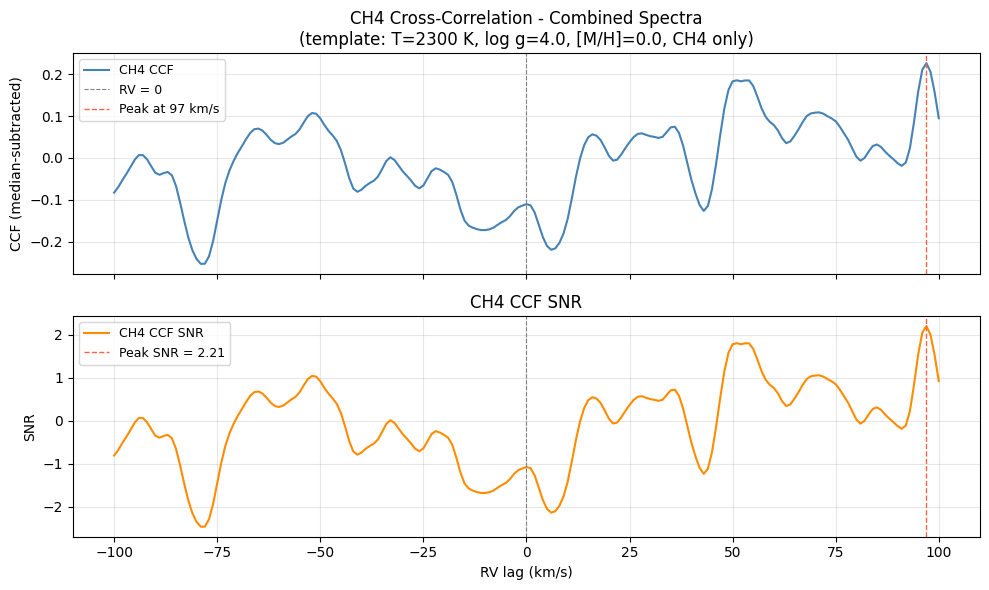

In [12]:
from scipy.interpolate import splrep, splev

#Follow the same CC workflow for CH4

#----- Load H2O template spectrum ----
h2o_template_path = workpath + '/spectra_input/planet_2300_4.0_-0.0_0_ch4_only.dat'
h2o_template = np.loadtxt(h2o_template_path)
ccf_model_w = h2o_template[0]
ccf_model_f = h2o_template[1]  

# Sort ascending in wavelength (required by splrep)
sort_idx    = np.argsort(ccf_model_w)
ccf_model_w = ccf_model_w[sort_idx]
ccf_model_f = ccf_model_f[sort_idx]

print(f'CO template: {len(ccf_model_w)} points, '
      f'wavelength {ccf_model_w.min()*1e9:.1f} - {ccf_model_w.max()*1e9:.1f} nm')

# ---- RV lag grid: -100 to +100 km/s, step 1 km/s ----
RVlag = np.arange(-100, 101, 1)   # 201 points
ncc   = len(RVlag)

# ---- Prepare the data cube ----
# extracted_spectra_combined shape: (nDet=3, nOrder=5, nPix=2048)
# Add singleton spatial axis -> (nDet, nOrder, n_spatial=1, nPix)
nDet, nOrder, nPix = extracted_spectra_combined.shape
cube_combined = extracted_spectra_combined[:, :, np.newaxis, :]  # (3, 5, 1, 2048)

print(f'Obs cube shape  : {cube_combined.shape}')
print(f'Wave grid shape : {wave_data.shape}')
print(f'RV lag          : {RVlag[0]} to {RVlag[-1]} km/s  ({ncc} steps)')

# ---- Instantiate cross-correlator ----
process_cc_combined = processor_cross_correlation(
    wMod      = ccf_model_w * 1e9,   # metres -> nm to match wave_data
    fMod      = ccf_model_f,
    wlen      = wave_data,            # (nDet, nOrder, nPix) in nm
    cube      = cube_combined,        # (nDet, nOrder, 1, nPix)
    nOrder    = nOrder,
    nDet      = nDet,
    n_spatial = 1
)

# ---- Run cross-correlation ----
ccf_sum, ccf_snr = process_cc_combined.ccf_tot(
    rvlag         = RVlag,
    ncc           = ncc,
    plot          = False,
    normalization = 'median subtracted',
    clean_grids = [(0, 50), (150, 200)]
)

# ccf_sum / ccf_snr shape (1, 201) -> squeeze to 1D
ccf_1d     = ccf_sum[0, :]
ccf_snr_1d = ccf_snr[0, :]

peak_rv  = RVlag[np.nanargmax(ccf_snr_1d)]
peak_snr = np.nanmax(ccf_snr_1d)
print(f'\nPeak CCF SNR = {peak_snr:.2f}  at  RV = {peak_rv:.1f} km/s')


#---- Run auto corss-correlation -----

#using spline interpolation and reshape the model flux to (nDet, nOrder, 1, nPix) to match the cube shape
ccf_model_f_int = np.zeros((nDet, nOrder, nPix))
coef_spline = interpolate.splrep(ccf_model_w * 1e9, ccf_model_f, s=0.0)  # spline coefficients for the model
splev = interpolate.splev  # ensure local name used below is defined
for iDet in range(nDet):
    for iOrder in range(nOrder):
        ccf_model_f_int[iDet, iOrder, :] = interpolate.splev(wave_data[iDet, iOrder, :], coef_spline, der=0)
        


ccf_model_f_reshaped = ccf_model_f_int[:, :, np.newaxis, :]  # (nDet, nOrder, 1, nPix)

process_cc_auto = processor_cross_correlation(
    wMod      = ccf_model_w * 1e9,   # metres -> nm to match wave_data
    fMod      = ccf_model_f,
    wlen      = wave_data,            # (nDet, nOrder, nPix) in nm
    cube      = ccf_model_f_reshaped,                  # (nDet, nOrder, 1, nPix)
    nOrder    = nOrder,
    nDet      = nDet,
    n_spatial = 1
)

ccf_auto, ccf_auto_snr = process_cc_auto.ccf_tot(
    rvlag         = RVlag,  
    ncc           = ncc,
    plot          = False,
    normalization = 'median subtracted',
    clean_grids = [(0, 50), (150, 200)]

)

ccf_auto_1d = ccf_auto[0, :]
ccf_auto_snr_1d = ccf_auto_snr[0, :]

peak_rv_auto = RVlag[np.nanargmax(ccf_auto_snr_1d)]
peak_snr_auto = np.nanmax(ccf_auto_snr_1d)
print(f'\nAuto CCF Peak SNR = {peak_snr_auto:.2f}  at  RV = {peak_rv_auto:.1f} km/s')

# ---- Plot results ----
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(RVlag, ccf_1d, color='steelblue', linewidth=1.5, label='CH4 CCF')
axes[0].axvline(0,       color='gray',   linestyle='--', linewidth=0.8, label='RV = 0')
axes[0].axvline(peak_rv, color='tomato', linestyle='--', linewidth=1.0,
                label=f'Peak at {peak_rv:.0f} km/s')

#axes[0].plot(RVlag, ccf_auto_1d, color='seagreen', linewidth=1.5, label='Auto CCF')



axes[0].set_ylabel('CCF (median-subtracted)')
axes[0].set_title('CH4 Cross-Correlation - Combined Spectra\n'
                  '(template: T=2300 K, log g=4.0, [M/H]=0.0, CH4 only)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(RVlag, ccf_snr_1d, color='darkorange', linewidth=1.5, label='CH4 CCF SNR')
axes[1].axvline(0,       color='gray',   linestyle='--', linewidth=0.8)
axes[1].axvline(peak_rv, color='tomato', linestyle='--', linewidth=1.0,
                label=f'Peak SNR = {peak_snr:.2f}')
axes[1].set_xlabel('RV lag (km/s)')
axes[1].set_ylabel('SNR')
axes[1].set_title('CH4 CCF SNR')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(workpath + night + '/ch4_ccf_combined_spectra.png', dpi=150, bbox_inches='tight')

plt.show()
